# Projet Analyse de Données — ACP pour Détection de Visage Réel/Fake

Ce notebook est corrigé et complété pour une structure de dataset du type :

```text
DATASET/
├── train_img/train_img/color/
├── train_img/train_img/depth/
├── test_img/test_img/color/
└── test_img/test_img/depth/
```

Objectif : transformer les images de visage en matrice de données, appliquer une ACP normée, interpréter l'ACP comme dans les TP, puis faire une classification binaire : **Real / Fake**.



In [390]:


import os
import re
import cv2
import json
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from tqdm.auto import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [391]:

# 2) CONFIGURATION DES CHEMINS


DATASET_DIR = Path('./DATASET')  # Local dataset folder

# Structure donnée par l'utilisateur
TRAIN_COLOR_DIR = DATASET_DIR / 'train_img' / 'train_img' / 'color'
TRAIN_DEPTH_DIR = DATASET_DIR / 'train_img' / 'train_img' / 'depth'
TEST_COLOR_DIR  = DATASET_DIR / 'test_img'  / 'test_img'  / 'color'
TEST_DEPTH_DIR  = DATASET_DIR / 'test_img'  / 'test_img'  / 'depth'

# Output directory for results
OUTPUT_DIR = Path('./ACP_RESULTATS_MAIL_BAROUD')
OUTPUT_DIR.mkdir(exist_ok=True)

# Choix de la modalité : 'color', 'depth', ou 'color_depth'
MODALITY = 'color'

# Taille des images pour l'ACP
IMG_SIZE = (64, 64)

# Nombre maximum d'images à utiliser pour aller vite dans Colab.
# Mets None pour utiliser tout le dataset.
MAX_TRAIN_IMAGES = None
MAX_TEST_IMAGES = None

# Taux d'inertie souhaité pour choisir le nombre de composantes principales
VARIANCE_TO_KEEP = 0.90
MAX_PCA_COMPONENTS = 150

print('DATASET_DIR =', DATASET_DIR)
for name, p in {
    'TRAIN_COLOR_DIR': TRAIN_COLOR_DIR,
    'TRAIN_DEPTH_DIR': TRAIN_DEPTH_DIR,
    'TEST_COLOR_DIR': TEST_COLOR_DIR,
    'TEST_DEPTH_DIR': TEST_DEPTH_DIR,
}.items():
    print(f'{name:16s}: {p} -> existe = {p.exists()}')


USE_CLAHE_FOR_ALL_IMAGES = True          
USE_CLASS_WEIGHT_BALANCED = True         
USE_BEST_AXES_FOR_CLASSIFICATION = True  
AXES_CANDIDATES = [20, 40, 59, 80, 100, 120, 150]
EXTERNAL_CONFIDENCE_THRESHOLD = 0.70     

CALIBRATE_REAL_THRESHOLD = True
REAL_THRESHOLD_MIN = 0.20
REAL_THRESHOLD_MAX = 0.80
REAL_THRESHOLD_STEP = 0.01

REAL_RECALL_PRIORITY = 0.15
BEST_REAL_THRESHOLD_FALLBACK = 0.35
EXTERNAL_VARIANT_MODE = 'face_priority'  

EXTERNAL_REAL_THRESHOLD_DEFAULT = 0.35    
EXTERNAL_FAKE_STRONG_THRESHOLD = 0.85     
EXTERNAL_UNCERTAINTY_MARGIN = 0.10        
USE_ACP_DISTANCE_REJECTION = True         
EXTERNAL_DISTANCE_PERCENTILE = 95.0       


USE_LOCAL_DATASET_COPY = False          
LOCAL_DATASET_DIR = Path('/content/dataset_cache')  
REBUILD_LOCAL_COPY = False              
USE_MATRIX_CACHE = True                 
REBUILD_MATRIX_CACHE = False            
CACHE_DIR_LOCAL = Path('./cache_local')
CACHE_DIR_DRIVE = Path('/content/drive/MyDrive/acp_face_cache')
CACHE_FILE_NAME = 'matrix_cache.joblib'
CACHE_FILE_LOCAL = CACHE_DIR_LOCAL / CACHE_FILE_NAME
CACHE_FILE_DRIVE = CACHE_DIR_DRIVE / CACHE_FILE_NAME
CACHE_SIGNATURE = 'v1.0_clahe_balanced_bestaxes'
LOAD_CACHE_FROM_DRIVE = False
SAVE_CACHE_TO_DRIVE = False

DATASET_DIR = DATASET
TRAIN_COLOR_DIR : DATASET\train_img\train_img\color -> existe = True
TRAIN_DEPTH_DIR : DATASET\train_img\train_img\depth -> existe = True
TEST_COLOR_DIR  : DATASET\test_img\test_img\color -> existe = True
TEST_DEPTH_DIR  : DATASET\test_img\test_img\depth -> existe = True


In [392]:

# 2 bis) ACCÉLÉRATION COLAB : COPIE LOCALE DU DATASET

import time
import shutil
import hashlib


def refresh_dataset_paths():
    """Recalcule les sous-dossiers train/test après changement de DATASET_DIR."""
    global TRAIN_COLOR_DIR, TRAIN_DEPTH_DIR, TEST_COLOR_DIR, TEST_DEPTH_DIR
    TRAIN_COLOR_DIR = DATASET_DIR / 'train_img' / 'train_img' / 'color'
    TRAIN_DEPTH_DIR = DATASET_DIR / 'train_img' / 'train_img' / 'depth'
    TEST_COLOR_DIR  = DATASET_DIR / 'test_img'  / 'test_img'  / 'color'
    TEST_DEPTH_DIR  = DATASET_DIR / 'test_img'  / 'test_img'  / 'depth'


def copy_dataset_to_content_if_needed():
    """Copie DATASET_DIR vers /content si demandé."""
    global DATASET_DIR

    if not USE_LOCAL_DATASET_COPY:
        print('Copie locale désactivée. DATASET_DIR reste :', DATASET_DIR)
        return

    original = Path(DATASET_DIR)
    local = Path(LOCAL_DATASET_DIR)

    if not original.exists():
        print('DATASET_DIR introuvable, copie impossible :', original)
        return

    # Si le dataset est déjà dans /content, inutile de copier.
    if str(original).startswith('/content/') and not str(original).startswith('/content/drive'):
        print('Dataset déjà local dans /content :', original)
        return

    start = time.time()
    if local.exists() and REBUILD_LOCAL_COPY:
        print('Suppression ancienne copie locale...')
        shutil.rmtree(local)

    if not local.exists():
        print('Copie du dataset vers /content. Cette étape peut prendre du temps une seule fois...')
        shutil.copytree(original, local)
    else:
        print('Copie locale déjà disponible :', local)

    DATASET_DIR = local
    refresh_dataset_paths()
    print('DATASET_DIR utilisé maintenant :', DATASET_DIR)
    print('Temps copie/vérification :', round(time.time() - start, 2), 'secondes')


copy_dataset_to_content_if_needed()

print('\nVérification des chemins après accélération :')
for name, p in {
    'TRAIN_COLOR_DIR': TRAIN_COLOR_DIR,
    'TRAIN_DEPTH_DIR': TRAIN_DEPTH_DIR,
    'TEST_COLOR_DIR': TEST_COLOR_DIR,
    'TEST_DEPTH_DIR': TEST_DEPTH_DIR,
}.items():
    print(f'{name:16s}: {p} -> existe = {p.exists()}')

# Création des dossiers cache
CACHE_DIR_LOCAL.mkdir(parents=True, exist_ok=True)
try:
    CACHE_DIR_DRIVE.mkdir(parents=True, exist_ok=True)
except Exception as e:
    print('Cache Drive non créé pour le moment :', e)


Copie locale désactivée. DATASET_DIR reste : DATASET

Vérification des chemins après accélération :
TRAIN_COLOR_DIR : DATASET\train_img\train_img\color -> existe = True
TRAIN_DEPTH_DIR : DATASET\train_img\train_img\depth -> existe = True
TEST_COLOR_DIR  : DATASET\test_img\test_img\color -> existe = True
TEST_DEPTH_DIR  : DATASET\test_img\test_img\depth -> existe = True


In [393]:
# ============================================================
# 3) UTILITAIRES : LISTE DES IMAGES ET AFFICHAGE
# ============================================================

IMAGE_EXTENSIONS = ['.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff']

def list_images(folder):
    folder = Path(folder)
    if not folder.exists():
        return []
    paths = [p for p in folder.rglob('*') if p.suffix.lower() in IMAGE_EXTENSIONS]
    return sorted(paths)

def limit_paths(paths, max_images=None):
    if max_images is None or len(paths) <= max_images:
        return paths
    rng = np.random.default_rng(RANDOM_STATE)
    idx = rng.choice(len(paths), size=max_images, replace=False)
    return [paths[i] for i in sorted(idx)]

train_color_paths = limit_paths(list_images(TRAIN_COLOR_DIR), MAX_TRAIN_IMAGES)
test_color_paths  = limit_paths(list_images(TEST_COLOR_DIR), MAX_TEST_IMAGES)

print('Nombre images train/color :', len(train_color_paths))
print('Nombre images test/color  :', len(test_color_paths))
print('Exemples train :')
for p in train_color_paths[:5]:
    print(' -', p)


Nombre images train/color : 1655
Nombre images test/color  : 475
Exemples train :
 - DATASET\train_img\train_img\color\10_1.avi_100_real.jpg
 - DATASET\train_img\train_img\color\10_1.avi_25_real.jpg
 - DATASET\train_img\train_img\color\10_1.avi_50_real.jpg
 - DATASET\train_img\train_img\color\10_1.avi_75_real.jpg
 - DATASET\train_img\train_img\color\10_2.avi_100_real.jpg


In [394]:
# 4) RECHERCHE AUTOMATIQUE DES FICHIERS LABELS


def find_label_files(root):
    root = Path(root)
    candidates = []
    if not root.exists():
        return []
    for p in root.rglob('*'):
        if p.is_file() and p.suffix.lower() in ['.txt', '.csv', '.tsv', '.json']:
            name = p.name.lower()
            if any(k in name for k in ['label', 'list', 'train', 'test', 'protocol', 'groundtruth', 'gt']):
                candidates.append(p)
    return sorted(candidates)

label_files = find_label_files(DATASET_DIR)
print('Fichiers labels/listes trouvés :')
for p in label_files:
    print(' -', p)

if len(label_files) == 0:
    print("\nAucun fichier label trouvé automatiquement.")
    print("Il faut chercher dans ton dataset un fichier comme train_label.txt, train_list.txt, label.csv, etc.")


Fichiers labels/listes trouvés :

Aucun fichier label trouvé automatiquement.
Il faut chercher dans ton dataset un fichier comme train_label.txt, train_list.txt, label.csv, etc.


In [395]:


LABEL_MAP = {
    '1': 1, 'real': 1, 'live': 1, 'genuine': 1, 'true': 1,
    '0': 0, 'fake': 0, 'spoof': 0, 'attack': 0, 'false': 0, 'print': 0, 'replay': 0, 'mask': 0,
}
CLASS_NAMES = {0: 'Fake', 1: 'Real'}

def normalize_key(s):
    s = str(s).strip()
    s = s.replace('\\', '/')
    return s.lower()

def keys_for_path(path, root=None):
    path = Path(path)
    keys = set()
    keys.add(normalize_key(path.name))
    keys.add(normalize_key(path.stem))
    keys.add(normalize_key(str(path)))
    if root is not None:
        try:
            keys.add(normalize_key(str(path.relative_to(root))))
        except Exception:
            pass
    
    parts = list(path.parts)
    for i in range(len(parts)):
        keys.add(normalize_key('/'.join(parts[i:])))
    return keys

def parse_label_token(token):
    t = str(token).strip().lower()
    t = t.replace(',', '').replace(';', '')
    if t in LABEL_MAP:
        return LABEL_MAP[t]
    
    m = re.search(r'[-+]?\d+', t)
    if m:
        val = m.group(0)
        if val in LABEL_MAP:
            return LABEL_MAP[val]
    return None

def read_label_file(label_path):
    label_path = Path(label_path)
    label_dict = {}
    if not label_path.exists():
        raise FileNotFoundError(label_path)

    if label_path.suffix.lower() == '.json':
        data = json.load(open(label_path, 'r', encoding='utf-8'))
        if isinstance(data, dict):
            iterable = data.items()
        else:
            iterable = []
        for k, v in iterable:
            lab = parse_label_token(v)
            if lab is not None:
                label_dict[normalize_key(k)] = lab
                label_dict[normalize_key(Path(str(k)).name)] = lab
        return label_dict

    
    with open(label_path, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()

    for line in lines:
        line = line.strip()
        if not line or line.startswith('#'):
            continue

        
        parts = re.split(r'[\s,;]+', line)
        parts = [p for p in parts if p != '']
        if len(parts) < 2:
            continue

        
        path_token = None
        for token in parts:
            tok = token.lower()
            if any(ext in tok for ext in IMAGE_EXTENSIONS) or '/' in tok or '\\' in tok:
                path_token = token
                break
        if path_token is None:
            path_token = parts[0]

        
        lab = None
        for token in reversed(parts):
            lab = parse_label_token(token)
            if lab is not None:
                break

        if lab is None:
            continue

        label_dict[normalize_key(path_token)] = lab
        label_dict[normalize_key(Path(path_token).name)] = lab
        label_dict[normalize_key(Path(path_token).stem)] = lab

    return label_dict

def merge_label_files(files):
    merged = {}
    for lf in files:
        try:
            d = read_label_file(lf)
            print(f'{lf.name}: {len(d)} labels lus')
            merged.update(d)
        except Exception as e:
            print('Impossible de lire', lf, '->', e)
    return merged

label_dict_all = merge_label_files(label_files)
print('\nTotal labels utilisables :', len(label_dict_all))
print('Exemples labels :', list(label_dict_all.items())[:10])



Total labels utilisables : 0
Exemples labels : []


In [396]:


def infer_label_from_path(path):
    s = normalize_key(str(path))
    fake_keywords = ['fake', 'spoof', 'attack', 'replay', 'print', 'photo', 'mask']
    real_keywords = ['real', 'live', 'genuine']
    if any(k in s for k in fake_keywords):
        return 0
    if any(k in s for k in real_keywords):
        return 1
    return None

def get_label_for_path(path, label_dict, root=None):
    for k in keys_for_path(path, root=root):
        if k in label_dict:
            return label_dict[k]
    return infer_label_from_path(path)


print('Test association label sur quelques images :')
for p in train_color_paths[:10]:
    print(p.name, '->', get_label_for_path(p, label_dict_all, DATASET_DIR))


Test association label sur quelques images :
10_1.avi_100_real.jpg -> 1
10_1.avi_25_real.jpg -> 1
10_1.avi_50_real.jpg -> 1
10_1.avi_75_real.jpg -> 1
10_2.avi_100_real.jpg -> 1
10_2.avi_125_real.jpg -> 1
10_2.avi_25_real.jpg -> 1
10_2.avi_50_real.jpg -> 1
10_2.avi_75_real.jpg -> 1
10_3.avi_25_fake.jpg -> 0


In [397]:

# 7) PRÉTRAITEMENT IMAGE : COLOR / DEPTH / COLOR_DEPTH

def cv2_read_image(path, flags=cv2.IMREAD_COLOR):
    """Lecture robuste d'une image avec OpenCV, même si le nom contient des espaces/accents."""
    path = str(path)
    data = np.fromfile(path, dtype=np.uint8)
    img = cv2.imdecode(data, flags)
    if img is None:
        img = cv2.imread(path, flags)
    return img


def apply_clahe_uint8(gray_u8):
    """Amélioration légère du contraste, appliquée de façon identique si activée."""
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(gray_u8)


def read_gray_resized(path, img_size=IMG_SIZE, use_clahe=USE_CLAHE_FOR_ALL_IMAGES):
    img = cv2_read_image(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    if use_clahe:
        img = apply_clahe_uint8(img)
    img = cv2.resize(img, img_size, interpolation=cv2.INTER_AREA)
    img = img.astype(np.float32) / 255.0
    return img


def find_matching_depth_path(color_path, color_root, depth_root):
    color_path = Path(color_path)
    try:
        rel = color_path.relative_to(color_root)
        candidate = depth_root / rel
        if candidate.exists():
            return candidate
    except Exception:
        pass

    # fallback : même nom dans depth
    matches = list(Path(depth_root).rglob(color_path.name)) if Path(depth_root).exists() else []
    if matches:
        return matches[0]
    return None


def preprocess_sample(color_path, modality='color', img_size=IMG_SIZE, color_root=None, depth_root=None):
    if modality == 'color':
        img = read_gray_resized(color_path, img_size)
        if img is None:
            return None
        return img.flatten()

    if modality == 'depth':
        depth_path = find_matching_depth_path(color_path, color_root, depth_root)
        if depth_path is None:
            return None
        img = read_gray_resized(depth_path, img_size)
        if img is None:
            return None
        return img.flatten()

    if modality == 'color_depth':
        img_c = read_gray_resized(color_path, img_size)
        depth_path = find_matching_depth_path(color_path, color_root, depth_root)
        img_d = read_gray_resized(depth_path, img_size) if depth_path is not None else None
        if img_c is None or img_d is None:
            return None
        return np.concatenate([img_c.flatten(), img_d.flatten()])

    raise ValueError("MODALITY doit être 'color', 'depth', ou 'color_depth'")


def load_dataset_from_color_paths(color_paths, color_root, depth_root, label_dict, dataset_root, require_labels=True, desc='Chargement'):
    X, y, paths_kept = [], [], []
    missing_labels = 0
    skipped_images = 0

    for p in tqdm(color_paths, desc=desc):
        lab = get_label_for_path(p, label_dict, root=dataset_root)
        if lab is None and require_labels:
            missing_labels += 1
            continue

        vec = preprocess_sample(p, modality=MODALITY, img_size=IMG_SIZE, color_root=color_root, depth_root=depth_root)
        if vec is None:
            skipped_images += 1
            continue

        X.append(vec)
        if lab is not None:
            y.append(lab)
        paths_kept.append(p)

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=int) if len(y) > 0 else None

    print(f'{desc}: X={X.shape}, y={None if y is None else y.shape}')
    print('Images ignorées sans label :', missing_labels)
    print('Images illisibles / depth manquant :', skipped_images)
    return X, y, paths_kept




# 7 bis) CHARGEMENT ACCÉLÉRÉ AVEC CACHE DES MATRICES X/y



def make_cache_signature():
    """Signature simple pour éviter de mélanger différents réglages."""
    
    raw = "|".join([
        str(MODALITY), str(IMG_SIZE), str(USE_CLAHE_FOR_ALL_IMAGES),
        str(MAX_TRAIN_IMAGES), str(MAX_TEST_IMAGES),
        str(len(train_color_paths)), str(len(test_color_paths)),
        str(train_color_paths[0].name if len(train_color_paths) else 'no_train'),
        str(test_color_paths[0].name if len(test_color_paths) else 'no_test'),
    ])
    return hashlib.md5(raw.encode('utf-8')).hexdigest()[:12]

CACHE_SIGNATURE = make_cache_signature()
CACHE_FILE_NAME = f'matrices_acp_{MODALITY}_{IMG_SIZE[0]}x{IMG_SIZE[1]}_clahe{int(USE_CLAHE_FOR_ALL_IMAGES)}_{CACHE_SIGNATURE}.npz'
CACHE_FILE_LOCAL = CACHE_DIR_LOCAL / CACHE_FILE_NAME
CACHE_FILE_DRIVE = CACHE_DIR_DRIVE / CACHE_FILE_NAME

print('Fichier cache local :', CACHE_FILE_LOCAL)
print('Fichier cache Drive :', CACHE_FILE_DRIVE)


def save_matrices_cache():
    """Sauvegarde X/y + chemins dans le cache local et éventuellement Drive."""
    y_test_is_none = y_test_raw is None
    y_test_to_save = np.array([], dtype=int) if y_test_raw is None else y_test_raw

    payload = dict(
        X_train_raw=X_train_raw,
        y_train_raw=y_train_raw,
        train_paths=np.array([str(p) for p in train_paths_kept], dtype=object),
        X_test_raw=X_test_raw,
        y_test_raw=y_test_to_save,
        y_test_is_none=np.array([y_test_is_none]),
        test_paths=np.array([str(p) for p in test_paths_kept], dtype=object),
        modality=np.array([MODALITY], dtype=object),
        img_size=np.array(IMG_SIZE),
        use_clahe=np.array([USE_CLAHE_FOR_ALL_IMAGES]),
    )

    np.savez_compressed(CACHE_FILE_LOCAL, **payload)
    print('Cache local sauvegardé :', CACHE_FILE_LOCAL)

    if SAVE_CACHE_TO_DRIVE:
        try:
            CACHE_DIR_DRIVE.mkdir(parents=True, exist_ok=True)
            shutil.copy2(CACHE_FILE_LOCAL, CACHE_FILE_DRIVE)
            print('Cache Drive sauvegardé :', CACHE_FILE_DRIVE)
        except Exception as e:
            print('Impossible de sauvegarder le cache Drive :', e)


def load_matrices_cache():
    """Charge les matrices depuis le cache local ou Drive."""
    global X_train_raw, y_train_raw, train_paths_kept, X_test_raw, y_test_raw, test_paths_kept

    candidates = []
    if CACHE_FILE_LOCAL.exists():
        candidates.append(CACHE_FILE_LOCAL)
    if LOAD_CACHE_FROM_DRIVE and CACHE_FILE_DRIVE.exists():
        candidates.append(CACHE_FILE_DRIVE)

    if len(candidates) == 0 or REBUILD_MATRIX_CACHE:
        return False

    cache_file = candidates[0]
    print('Chargement des matrices depuis le cache :', cache_file)
    data = np.load(cache_file, allow_pickle=True)

    X_train_raw = data['X_train_raw']
    y_train_raw = data['y_train_raw']
    train_paths_kept = [Path(s) for s in data['train_paths'].tolist()]
    X_test_raw = data['X_test_raw']
    y_test_is_none = bool(data['y_test_is_none'][0])
    y_test_raw = None if y_test_is_none else data['y_test_raw']
    test_paths_kept = [Path(s) for s in data['test_paths'].tolist()]

    
    if cache_file == CACHE_FILE_DRIVE and not CACHE_FILE_LOCAL.exists():
        try:
            shutil.copy2(CACHE_FILE_DRIVE, CACHE_FILE_LOCAL)
        except Exception:
            pass

    print('Cache chargé avec succès.')
    print('X_train_raw =', X_train_raw.shape, '| y_train_raw =', y_train_raw.shape)
    print('X_test_raw  =', X_test_raw.shape,  '| y_test_raw  =', None if y_test_raw is None else y_test_raw.shape)
    return True


if USE_MATRIX_CACHE and load_matrices_cache():
    print('Lecture des images évitée grâce au cache.')
else:
    print('Cache absent ou reconstruction forcée : lecture des images...')
    X_train_raw, y_train_raw, train_paths_kept = load_dataset_from_color_paths(
        train_color_paths, TRAIN_COLOR_DIR, TRAIN_DEPTH_DIR, label_dict_all, DATASET_DIR,
        require_labels=True, desc='Train'
    )

    X_test_raw, y_test_raw, test_paths_kept = load_dataset_from_color_paths(
        test_color_paths, TEST_COLOR_DIR, TEST_DEPTH_DIR, label_dict_all, DATASET_DIR,
        require_labels=False, desc='Test'
    )

    if USE_MATRIX_CACHE:
        save_matrices_cache()

if X_train_raw.shape[0] == 0 or y_train_raw is None or len(np.unique(y_train_raw)) < 2:
    raise ValueError("""
Aucun entraînement possible : les labels Real/Fake ne sont pas trouvés ou une seule classe est détectée.
Solution : vérifie le fichier de labels du dataset. Il doit contenir le chemin/nom de l'image et son label.
Exemple : image_001.jpg 1 ; image_002.jpg 0, avec 1=Real et 0=Fake.
""")

print('\nDistribution train :')
print(pd.Series(y_train_raw).map(CLASS_NAMES).value_counts())
if y_test_raw is not None and len(y_test_raw) > 0 and len(y_test_raw) == X_test_raw.shape[0]:
    print('\nDistribution test :')
    print(pd.Series(y_test_raw).map(CLASS_NAMES).value_counts())
else:
    print('\nLabels test absents ou incomplets : le test officiel sera utilisé seulement comme prédiction externe si nécessaire.')


Fichier cache local : cache_local\matrices_acp_color_64x64_clahe1_f6a9aa871e23.npz
Fichier cache Drive : \content\drive\MyDrive\acp_face_cache\matrices_acp_color_64x64_clahe1_f6a9aa871e23.npz
Chargement des matrices depuis le cache : cache_local\matrices_acp_color_64x64_clahe1_f6a9aa871e23.npz
Cache chargé avec succès.
X_train_raw = (1655, 4096) | y_train_raw = (1655,)
X_test_raw  = (475, 4096) | y_test_raw  = (475,)
Lecture des images évitée grâce au cache.

Distribution train :
Fake    1251
Real     404
Name: count, dtype: int64

Distribution test :
Fake    346
Real    129
Name: count, dtype: int64


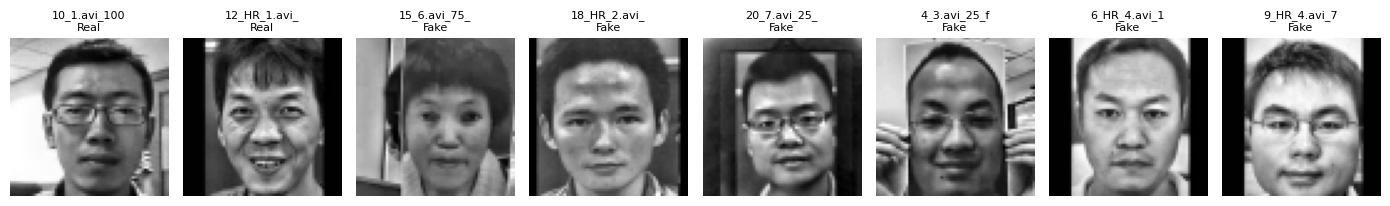

In [398]:

# 8) AFFICHER QUELQUES IMAGES


def show_samples(paths, labels=None, n=8):
    if len(paths) == 0:
        print('Aucune image à afficher.')
        return
    n = min(n, len(paths))
    idx = np.linspace(0, len(paths)-1, n, dtype=int)
    plt.figure(figsize=(14, 3))
    for j, i in enumerate(idx):
        img = read_gray_resized(paths[i], IMG_SIZE)
        plt.subplot(1, n, j+1)
        plt.imshow(img, cmap='gray')
        title = paths[i].name[:12]
        if labels is not None and len(labels) > i:
            title += f"\n{CLASS_NAMES[int(labels[i])]}"
        plt.title(title, fontsize=8)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_samples(train_paths_kept, y_train_raw, n=8)


In [399]:

# 9) MATRICE DES DONNÉES X + NORMALISATION Z

X = X_train_raw
y = y_train_raw

print('Matrice X :', X.shape)
print("Nombre d'individus/images m =", X.shape[0])
print('Nombre de variables/pixels n =', X.shape[1])

# Quelques statistiques comme TP1
mean_vector = X.mean(axis=0)
var_vector = X.var(axis=0)
std_vector = X.std(axis=0)
print('Moyenne globale des pixels :', X.mean())
print('Variance globale des pixels :', X.var())

scaler = StandardScaler(with_mean=True, with_std=True)
Z = scaler.fit_transform(X)
print('Matrice centrée-réduite Z :', Z.shape)


Matrice X : (1655, 4096)
Nombre d'individus/images m = 1655
Nombre de variables/pixels n = 4096
Moyenne globale des pixels : 0.41749224
Variance globale des pixels : 0.05888827
Matrice centrée-réduite Z : (1655, 4096)


In [436]:
# Affichage de quelques lignes de la matrice X
import pandas as pd

n_pixels_affichés = 10  # on affiche seulement les 10 premiers pixels

df_X = pd.DataFrame(
    X[:6, :n_pixels_affichés],
    columns=[f'px({i//64},{i%64})' for i in range(n_pixels_affichés)]
)
df_X.insert(0, 'Image', [p.name for p in train_paths_kept[:6]])

print(f"Matrice X : {X.shape[0]} images × {X.shape[1]} pixels (affichage des 6 premières lignes, 10 premiers pixels)")
display(df_X.round(4))

Matrice X : 1655 images × 4096 pixels (affichage des 6 premières lignes, 10 premiers pixels)


,Image,"px(0,0)","px(0,1)","px(0,2)","px(0,3)","px(0,4)","px(0,5)","px(0,6)","px(0,7)","px(0,8)","px(0,9)"
0,10_1.avi_100_real.jpg,0.6784,0.6667,0.6667,0.6235,0.6157,0.6471,0.6667,0.6745,0.6549,0.6235
1,10_1.avi_25_real.jpg,0.7569,0.7020,0.6549,0.6706,0.7059,0.6902,0.6588,0.6588,0.6667,0.7059
2,10_1.avi_50_real.jpg,0.6667,0.6667,0.6627,0.6549,0.6510,0.6510,0.6667,0.6784,0.6549,0.6157
3,10_1.avi_75_real.jpg,0.4980,0.4980,0.4941,0.5216,0.4980,0.5647,0.5020,0.4235,0.3765,0.3020
4,10_2.avi_100_real.jpg,0.3686,0.8353,0.6235,0.5569,0.5529,0.5725,0.5882,0.6000,0.6039,0.6275
5,10_2.avi_125_real.jpg,0.3686,0.8314,0.6157,0.5373,0.5686,0.5686,0.5843,0.5647,0.5804,0.5961


In [400]:

# 10) SPLIT VALIDATION OU TEST OFFICIEL


X_tr, X_val, y_tr, y_val, paths_tr, paths_val = train_test_split(
    X, y, train_paths_kept, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

scaler_model = StandardScaler(with_mean=True, with_std=True)
Z_tr = scaler_model.fit_transform(X_tr)
Z_val = scaler_model.transform(X_val)

print('Train interne :', Z_tr.shape, pd.Series(y_tr).map(CLASS_NAMES).value_counts().to_dict())
print('Validation interne :', Z_val.shape, pd.Series(y_val).map(CLASS_NAMES).value_counts().to_dict())


Train interne : (1241, 4096) {'Fake': 938, 'Real': 303}
Validation interne : (414, 4096) {'Fake': 313, 'Real': 101}


In [401]:

# 11) ACP NORMÉE : VALEURS PROPRES, INERTIE, AXES


max_comp = min(MAX_PCA_COMPONENTS, Z_tr.shape[0] - 1, Z_tr.shape[1])
if max_comp < 2:
    raise ValueError('Pas assez de données pour faire une ACP avec au moins 2 composantes.')

pca_full = PCA(n_components=max_comp, svd_solver='randomized', random_state=RANDOM_STATE)
C_tr_full = pca_full.fit_transform(Z_tr)
C_val_full = pca_full.transform(Z_val)

eigenvalues = pca_full.explained_variance_
inertia_ratio = pca_full.explained_variance_ratio_
cum_inertia = np.cumsum(inertia_ratio)

if cum_inertia[-1] >= VARIANCE_TO_KEEP:
    n_selected = int(np.searchsorted(cum_inertia, VARIANCE_TO_KEEP) + 1)
else:
    n_selected = max_comp

print('Nombre max de composantes calculées :', max_comp)
print(f'Nombre de composantes retenues pour {VARIANCE_TO_KEEP*100:.0f}% inertie :', n_selected)
print('Inertie cumulée retenue :', cum_inertia[n_selected-1])

acp_table = pd.DataFrame({
    'Axe': [f'F{i+1}' for i in range(len(eigenvalues))],
    'Valeur propre': eigenvalues,
    'Taux inertie (%)': inertia_ratio * 100,
    'Inertie cumulée (%)': cum_inertia * 100,
})
acp_table.head(15)


Nombre max de composantes calculées : 150
Nombre de composantes retenues pour 90% inertie : 115
Inertie cumulée retenue : 0.90010506


,Axe,Valeur propre,Taux inertie (%),Inertie cumulée (%)
0,F1,796.053589,19.419237,19.419237
1,F2,464.367340,11.327955,30.747192
2,F3,281.151489,6.858517,37.605709
3,F4,189.804947,4.630175,42.235886
4,F5,142.568024,3.477859,45.713745
5,F6,119.855835,2.923809,48.637554
6,F7,97.452301,2.377289,51.014839
7,F8,84.032349,2.049917,53.064758
8,F9,79.075249,1.928992,54.993748
9,F10,73.044998,1.781888,56.775635


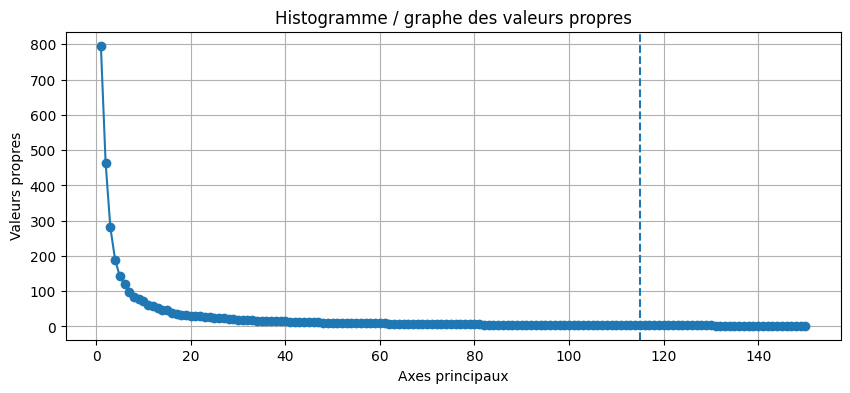

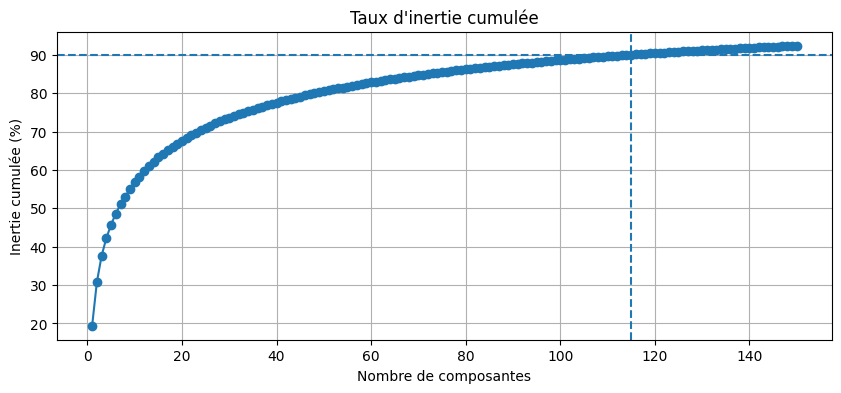

In [402]:
# ============================================================
# 12) GRAPHIQUES : VALEURS PROPRES ET INERTIE CUMULÉE
# ============================================================

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(eigenvalues)+1), eigenvalues, marker='o')
plt.axvline(n_selected, linestyle='--')
plt.title('Histogramme / graphe des valeurs propres')
plt.xlabel('Axes principaux')
plt.ylabel('Valeurs propres')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(cum_inertia)+1), cum_inertia*100, marker='o')
plt.axhline(VARIANCE_TO_KEEP*100, linestyle='--')
plt.axvline(n_selected, linestyle='--')
plt.title("Taux d'inertie cumulée")
plt.xlabel('Nombre de composantes')
plt.ylabel('Inertie cumulée (%)')
plt.grid(True)
plt.show()


In [403]:
# ============================================================
# 13) PROJECTION DES INDIVIDUS SUR LES AXES RETENUS
# ============================================================

C_tr = C_tr_full[:, :n_selected]
C_val = C_val_full[:, :n_selected]

proj_train_table = pd.DataFrame(C_tr[:, :min(3, n_selected)], columns=[f'C{i+1}' for i in range(min(3, n_selected))])
proj_train_table.insert(0, 'Classe', pd.Series(y_tr).map(CLASS_NAMES).values)
proj_train_table.insert(0, 'Image', [p.name for p in paths_tr])
proj_train_table.head(10)


,Image,Classe,C1,C2,C3
0,9_8.avi_125_fake.jpg,Fake,-10.758706,24.074398,12.276628
1,1_7.avi_175_fake.jpg,Fake,10.064584,59.406963,-5.231588
2,4_6.avi_125_fake.jpg,Fake,16.931215,-28.320925,-13.079819
3,16_8.avi_100_fake.jpg,Fake,-14.170629,15.104831,-6.512293
4,3_3.avi_50_fake.jpg,Fake,35.471058,-6.715651,-29.676414
5,4_8.avi_175_fake.jpg,Fake,-19.209032,-24.544720,-0.208316
6,17_HR_3.avi_75_fake.jpg,Fake,-33.049030,-22.542339,-7.246136
7,13_7.avi_75_fake.jpg,Fake,-7.176194,25.304707,26.991423
8,4_HR_2.avi_200_fake.jpg,Fake,-35.593460,-34.366028,3.051155
9,11_HR_3.avi_50_fake.jpg,Fake,-14.282833,-10.641264,15.187930


## 13 bis) Choix du nombre d’axes pour la classification



In [404]:

# 13 bis) TEST DE PLUSIEURS NOMBRES D'AXES ACP POUR LA CLASSIFICATION


candidate_axes = sorted(set([c for c in AXES_CANDIDATES if 2 <= c <= C_tr_full.shape[1]] + [n_selected]))
axes_results = []

for nb_axes in candidate_axes:
    Ctr_tmp = C_tr_full[:, :nb_axes]
    Cval_tmp = C_val_full[:, :nb_axes]

    clf_tmp = SVC(
        kernel='rbf',
        C=10,
        gamma='scale',
        class_weight='balanced' if USE_CLASS_WEIGHT_BALANCED else None,
        probability=True,
        random_state=RANDOM_STATE
    )
    clf_tmp.fit(Ctr_tmp, y_tr)
    pred_tmp = clf_tmp.predict(Cval_tmp)

    axes_results.append({
        "Nombre d'axes": nb_axes,
        "Inertie cumulée (%)": float(cum_inertia[nb_axes-1] * 100),
        "Accuracy": accuracy_score(y_val, pred_tmp),
        "Balanced accuracy": balanced_accuracy_score(y_val, pred_tmp),
        "F1-score macro": f1_score(y_val, pred_tmp, average='macro'),
        "Real prédits Fake": int(((y_val == 1) & (pred_tmp == 0)).sum()),
        "Fake prédits Real": int(((y_val == 0) & (pred_tmp == 1)).sum()),
    })

axes_results_df = pd.DataFrame(axes_results).sort_values(
    ["Balanced accuracy", "F1-score macro", "Nombre d'axes"],
    ascending=[False, False, True]
)

display(axes_results_df)

n_selected_inertia = n_selected
if USE_BEST_AXES_FOR_CLASSIFICATION:
    n_selected_model = int(axes_results_df.iloc[0]["Nombre d'axes"])
else:
    n_selected_model = n_selected_inertia

# À partir de maintenant, C_tr et C_val utilisent le nombre d'axes choisi pour la classification.
n_selected = n_selected_model
C_tr = C_tr_full[:, :n_selected]
C_val = C_val_full[:, :n_selected]

print(f"Axes retenus par inertie : {n_selected_inertia} axes => {cum_inertia[n_selected_inertia-1]*100:.2f}%")
print(f"Axes utilisés pour le modèle final : {n_selected} axes => {cum_inertia[n_selected-1]*100:.2f}%")
print("Remarque : si les deux nombres sont différents, on le mentionne dans le rapport comme optimisation validée expérimentalement.")

,Nombre d'axes,Inertie cumulée (%),Accuracy,Balanced accuracy,F1-score macro,Real prédits Fake,Fake prédits Real
7,150,92.357857,0.978261,0.962152,0.970026,7,2
5,115,90.010506,0.975845,0.960554,0.966811,7,3
6,120,90.415802,0.975845,0.960554,0.966811,7,3
1,40,77.562141,0.973430,0.958957,0.963618,7,4
3,80,86.204079,0.975845,0.957201,0.966578,8,2
4,100,88.622978,0.975845,0.957201,0.966578,8,2
0,20,67.545944,0.973430,0.955604,0.963365,8,3
2,59,82.593033,0.973430,0.955604,0.963365,8,3


Axes retenus par inertie : 115 axes => 90.01%
Axes utilisés pour le modèle final : 150 axes => 92.36%
Remarque : si les deux nombres sont différents, on le mentionne dans le rapport comme optimisation validée expérimentalement.


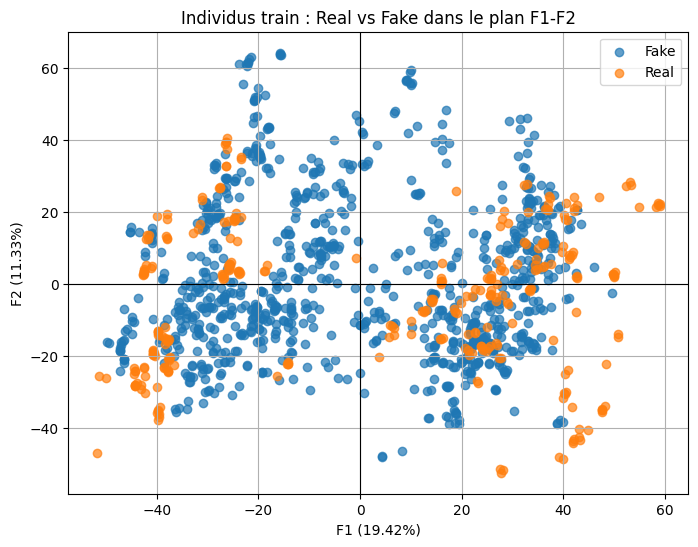

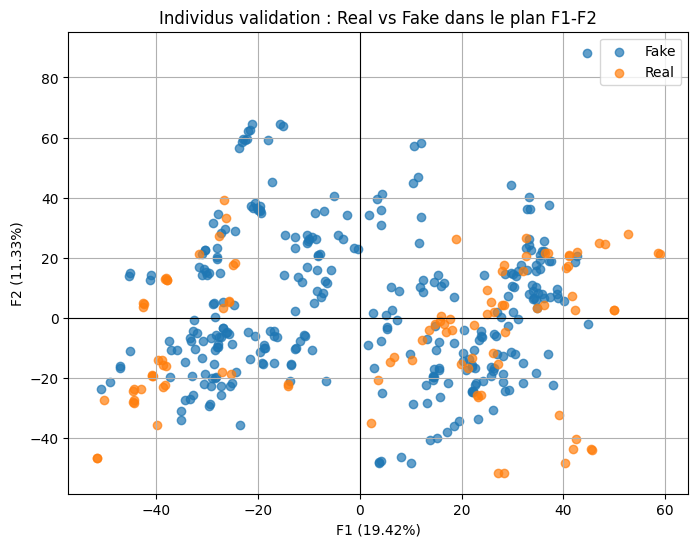

In [405]:

# 14) GRAPHE DES INDIVIDUS DANS LE PLAN FACTORIEL F1-F2


def plot_individuals(C, y, title='Projection des individus F1-F2'):
    plt.figure(figsize=(8, 6))
    for lab in np.unique(y):
        idx = (y == lab)
        plt.scatter(C[idx, 0], C[idx, 1], label=CLASS_NAMES[int(lab)], alpha=0.7)
    plt.axhline(0, color='black', linewidth=0.8)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.xlabel(f'F1 ({inertia_ratio[0]*100:.2f}%)')
    plt.ylabel(f'F2 ({inertia_ratio[1]*100:.2f}%)')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_individuals(C_tr_full, y_tr, 'Individus train : Real vs Fake dans le plan F1-F2')
plot_individuals(C_val_full, y_val, 'Individus validation : Real vs Fake dans le plan F1-F2')


In [406]:

# 15) QUALITÉ DE REPRÉSENTATION DES INDIVIDUS : cos²


def individual_cos2(Z_data, C_data, paths, y_data, n_axes=3):
    n_axes = min(n_axes, C_data.shape[1])
    dist2 = np.sum(Z_data**2, axis=1)
    dist2[dist2 == 0] = 1e-12
    cos2 = (C_data[:, :n_axes] ** 2) / dist2[:, None]
    df = pd.DataFrame(cos2, columns=[f'Qualité axe F{i+1}' for i in range(n_axes)])
    df.insert(0, 'Classe', pd.Series(y_data).map(CLASS_NAMES).values)
    df.insert(0, 'Image', [p.name for p in paths])
    return df

cos2_ind_train = individual_cos2(Z_tr, C_tr_full, paths_tr, y_tr, n_axes=3)
cos2_ind_train.head(15)


,Image,Classe,Qualité axe F1,Qualité axe F2,Qualité axe F3
0,9_8.avi_125_fake.jpg,Fake,0.043070,0.215657,0.056080
1,1_7.avi_175_fake.jpg,Fake,0.016828,0.586308,0.004547
2,4_6.avi_125_fake.jpg,Fake,0.090334,0.252749,0.053911
3,16_8.avi_100_fake.jpg,Fake,0.096271,0.109382,0.020332
4,3_3.avi_50_fake.jpg,Fake,0.234728,0.008414,0.164301
5,4_8.avi_175_fake.jpg,Fake,0.121879,0.198991,0.000014
6,17_HR_3.avi_75_fake.jpg,Fake,0.272384,0.126725,0.013094
7,13_7.avi_75_fake.jpg,Fake,0.011895,0.147901,0.168276
8,4_HR_2.avi_200_fake.jpg,Fake,0.283398,0.264189,0.002082
9,11_HR_3.avi_50_fake.jpg,Fake,0.066834,0.037099,0.075573


In [407]:

# 16) CONTRIBUTION DES INDIVIDUS À L'INERTIE DES AXES

def individual_contributions(C_data, paths, y_data, n_axes=3):
    n_axes = min(n_axes, C_data.shape[1])
    scores2 = C_data[:, :n_axes] ** 2
    denom = scores2.sum(axis=0)
    denom[denom == 0] = 1e-12
    contrib = 100 * scores2 / denom
    df = pd.DataFrame(contrib, columns=[f'Contribution F{i+1} (%)' for i in range(n_axes)])
    df.insert(0, 'Classe', pd.Series(y_data).map(CLASS_NAMES).values)
    df.insert(0, 'Image', [p.name for p in paths])
    return df

contrib_ind_train = individual_contributions(C_tr_full, paths_tr, y_tr, n_axes=3)
contrib_ind_train.head(15)


,Image,Classe,Contribution F1 (%),Contribution F2 (%),Contribution F3 (%)
0,9_8.avi_125_fake.jpg,Fake,0.011726,0.100653,0.043231
1,1_7.avi_175_fake.jpg,Fake,0.010262,0.612903,0.007851
2,4_6.avi_125_fake.jpg,Fake,0.029041,0.139294,0.049073
3,16_8.avi_100_fake.jpg,Fake,0.020343,0.039623,0.012165
4,3_3.avi_50_fake.jpg,Fake,0.127463,0.007832,0.252616
5,4_8.avi_175_fake.jpg,Fake,0.037381,0.104624,0.000012
6,17_HR_3.avi_75_fake.jpg,Fake,0.110651,0.088250,0.015061
7,13_7.avi_75_fake.jpg,Fake,0.005217,0.111204,0.208973
8,4_HR_2.avi_200_fake.jpg,Fake,0.128344,0.205105,0.002670
9,11_HR_3.avi_50_fake.jpg,Fake,0.020666,0.019665,0.066166


In [408]:

# 17) INDIVIDUS MAL REPRÉSENTÉS SUR LE PLAN F1-F2


cos2_plane = cos2_ind_train['Qualité axe F1'] + cos2_ind_train['Qualité axe F2']
mal_represented = cos2_ind_train.copy()
mal_represented['Qualité plan F1-F2'] = cos2_plane
mal_represented['Signe F1'] = np.where(C_tr_full[:, 0] >= 0, '+', '-')
mal_represented['Signe F2'] = np.where(C_tr_full[:, 1] >= 0, '+', '-')
mal_represented = mal_represented.sort_values('Qualité plan F1-F2')
mal_represented.head(20)


,Image,Classe,Qualité axe F1,Qualité axe F2,Qualité axe F3,Qualité plan F1-F2,Signe F1,Signe F2
1186,7_HR_2.avi_150_fake.jpg,Fake,0.000204,0.000289,0.120389,0.000493,-,-
912,18_5.avi_50_fake.jpg,Fake,0.001867,0.000444,0.079023,0.002311,+,-
12,7_HR_2.avi_125_fake.jpg,Fake,0.001417,0.004315,0.106658,0.005732,+,+
463,12_8.avi_175_fake.jpg,Fake,0.009651,0.000077,0.023518,0.009729,-,+
784,11_5.avi_25_fake.jpg,Fake,0.010245,0.000463,0.024842,0.010708,+,-
757,18_5.avi_75_fake.jpg,Fake,0.010975,0.000004,0.107784,0.010979,+,-
858,5_HR_1.avi_125_real.jpg,Real,0.000192,0.012218,0.245696,0.012409,-,+
839,18_6.avi_25_fake.jpg,Fake,0.001907,0.017141,0.030042,0.019048,+,-
672,12_8.avi_150_fake.jpg,Fake,0.020275,0.001665,0.047687,0.021940,-,+
823,20_8.avi_50_fake.jpg,Fake,0.022039,0.000706,0.208845,0.022746,-,+


In [409]:

# 18) ANALYSE DES VARIABLES / PIXELS : COORDONNÉES SUR LES AXES

n_axes_var = min(3, pca_full.components_.shape[0])
var_coords = pca_full.components_[:n_axes_var].T * np.sqrt(pca_full.explained_variance_[:n_axes_var])

def pixel_labels(n_features, img_size=IMG_SIZE, modality=MODALITY):
    h, w = img_size[1], img_size[0]
    base_n = h * w
    labels = []
    if modality in ['color', 'depth']:
        prefix = 'px' if modality == 'color' else 'dpx'
        for idx in range(n_features):
            r, c = divmod(idx, w)
            labels.append(f'{prefix}({r},{c})')
    else:
        for idx in range(n_features):
            part = 'color' if idx < base_n else 'depth'
            local = idx if idx < base_n else idx - base_n
            r, c = divmod(local, w)
            labels.append(f'{part}({r},{c})')
    return labels

var_labels = pixel_labels(X.shape[1], IMG_SIZE, MODALITY)
var_table = pd.DataFrame(var_coords, columns=[f'Coord F{i+1}' for i in range(n_axes_var)])
var_table.insert(0, 'Variable', var_labels)
var_table.head(10)


,Variable,Coord F1,Coord F2,Coord F3
0,"px(0,0)",0.836790,-0.122031,-0.008043
1,"px(0,1)",0.850174,-0.110731,0.023903
2,"px(0,2)",0.857900,-0.106241,0.029777
3,"px(0,3)",0.857845,-0.118997,0.037776
4,"px(0,4)",0.855185,-0.123545,0.036612
5,"px(0,5)",0.845213,-0.110432,0.035735
6,"px(0,6)",0.845638,-0.103179,0.035249
7,"px(0,7)",0.833734,-0.086407,0.039555
8,"px(0,8)",0.824019,-0.085311,0.039850
9,"px(0,9)",0.709698,-0.089791,0.020543


In [410]:

# 19) QUALITÉ ET CONTRIBUTION DES VARIABLES


var_cos2 = var_coords ** 2
var_contrib = 100 * var_cos2 / pca_full.explained_variance_[:n_axes_var]

var_quality_table = pd.DataFrame(var_cos2, columns=[f'Qualité F{i+1}' for i in range(n_axes_var)])
var_quality_table.insert(0, 'Variable', var_labels)

var_contrib_table = pd.DataFrame(var_contrib, columns=[f'Contribution F{i+1} (%)' for i in range(n_axes_var)])
var_contrib_table.insert(0, 'Variable', var_labels)

# Top pixels qui expliquent le plus F1-F2
top_score = var_contrib[:, 0] + var_contrib[:, 1]
top_idx = np.argsort(top_score)[::-1][:20]

print('Top 20 variables/pixels les plus importantes pour F1-F2 :')
display(var_contrib_table.iloc[top_idx])


Top 20 variables/pixels les plus importantes pour F1-F2 :


,Variable,Contribution F1 (%),Contribution F2 (%),Contribution F3 (%)
2670,"px(41,46)",0.000014,0.130598,0.002419
2669,"px(41,45)",0.000088,0.130124,0.003166
2606,"px(40,46)",0.000036,0.129122,0.004915
2733,"px(42,45)",0.000658,0.126090,0.000101
2671,"px(41,47)",0.000004,0.126716,0.001877
2605,"px(40,45)",0.000037,0.126329,0.006968
2734,"px(42,46)",0.000304,0.124559,0.000215
2607,"px(40,47)",0.000007,0.124421,0.004113
2775,"px(43,23)",0.001539,0.122239,0.000007
2711,"px(42,23)",0.000895,0.122083,0.000477


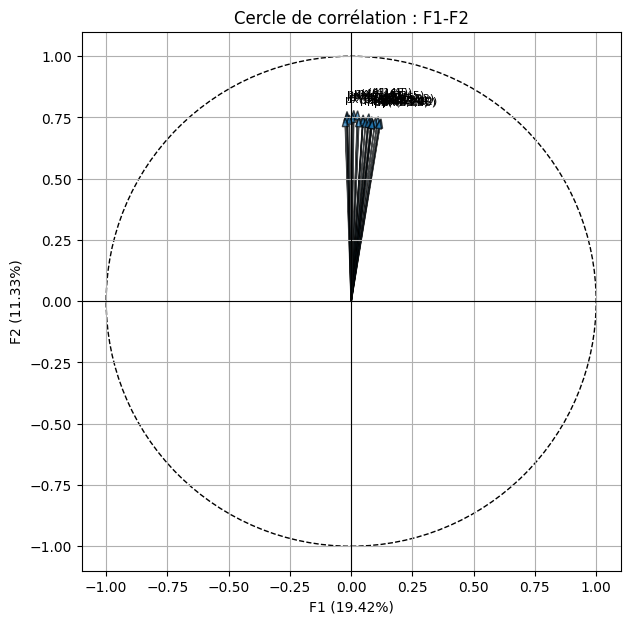

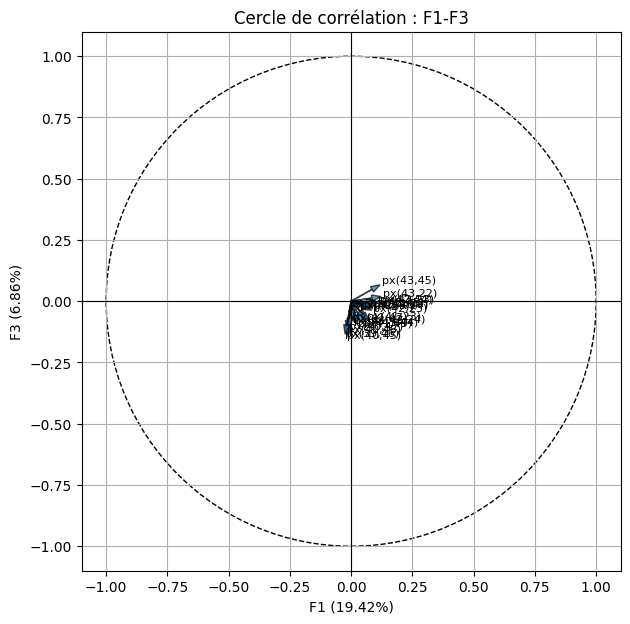

In [411]:

# 20) CERCLE DE CORRÉLATION DES VARIABLES IMPORTANTES


def plot_correlation_circle(var_coords, top_idx, ax1=0, ax2=1, title='Cercle de corrélation'):
    fig, ax = plt.subplots(figsize=(7, 7))
    circle = plt.Circle((0, 0), 1, fill=False, linestyle='--')
    ax.add_artist(circle)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvline(0, color='black', linewidth=0.8)

    for idx in top_idx:
        x = var_coords[idx, ax1]
        y = var_coords[idx, ax2]
        ax.arrow(0, 0, x, y, head_width=0.025, length_includes_head=True, alpha=0.7)
        ax.text(x*1.08, y*1.08, var_labels[idx], fontsize=8)

    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect('equal', 'box')
    ax.set_xlabel(f'F{ax1+1} ({inertia_ratio[ax1]*100:.2f}%)')
    ax.set_ylabel(f'F{ax2+1} ({inertia_ratio[ax2]*100:.2f}%)')
    ax.set_title(title)
    ax.grid(True)
    plt.show()

plot_correlation_circle(var_coords, top_idx, 0, 1, 'Cercle de corrélation : F1-F2')
if n_axes_var >= 3:
    plot_correlation_circle(var_coords, top_idx, 0, 2, 'Cercle de corrélation : F1-F3')


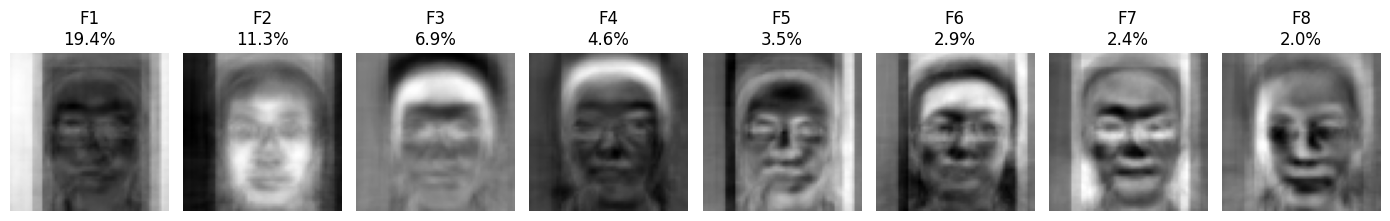

In [412]:

# 21) EIGENFACES / COMPOSANTES PRINCIPALES SOUS FORME D'IMAGES


def show_eigenfaces(pca, img_size=IMG_SIZE, n=8, modality=MODALITY):
    n = min(n, pca.components_.shape[0])
    w, h = img_size
    plt.figure(figsize=(14, 3))
    for i in range(n):
        comp = pca.components_[i]
        if modality == 'color_depth':
            comp = comp[:w*h]  # affiche seulement partie color
        img = comp.reshape(h, w)
        plt.subplot(1, n, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(f'F{i+1}\n{inertia_ratio[i]*100:.1f}%')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_eigenfaces(pca_full, IMG_SIZE, n=8, modality=MODALITY)


In [413]:

# 22) CLASSIFICATION REAL / FAKE APRÈS ACP


balanced_weight = 'balanced' if USE_CLASS_WEIGHT_BALANCED else None

models = {
    'Logistic Regression équilibrée': LogisticRegression(max_iter=3000, class_weight=balanced_weight, random_state=RANDOM_STATE),
    'SVM Linear équilibré': SVC(kernel='linear', C=1, class_weight=balanced_weight, probability=True, random_state=RANDOM_STATE),
    'SVM RBF équilibré': SVC(kernel='rbf', C=10, gamma='scale', class_weight=balanced_weight, probability=True, random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Random Forest équilibré': RandomForestClassifier(n_estimators=250, class_weight=balanced_weight, random_state=RANDOM_STATE),
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(C_tr, y_tr)
    y_pred = model.predict(C_val)
    results.append({
        'Modèle': name,
        'Accuracy validation': accuracy_score(y_val, y_pred),
        'Balanced accuracy': balanced_accuracy_score(y_val, y_pred),
        'F1-score macro': f1_score(y_val, y_pred, average='macro'),
        'Real prédits Fake': int(((y_val == 1) & (y_pred == 0)).sum()),
        'Fake prédits Real': int(((y_val == 0) & (y_pred == 1)).sum()),
    })
    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values(['Balanced accuracy', 'F1-score macro'], ascending=False)
display(results_df)

,Modèle,Accuracy validation,Balanced accuracy,F1-score macro,Real prédits Fake,Fake prédits Real
2,SVM RBF équilibré,0.978261,0.962152,0.970026,7,2
0,Logistic Regression équilibrée,0.910628,0.907364,0.885147,10,27
1,SVM Linear équilibré,0.905797,0.900816,0.878939,11,28
4,Random Forest équilibré,0.932367,0.861386,0.898134,28,0
3,KNN,0.913043,0.855313,0.875188,26,10


Meilleur modèle : SVM RBF équilibré
Nombre d'axes ACP utilisés : 150
Accuracy validation : 0.9782608695652174
Balanced accuracy : 0.9621516464745516
F1-score macro : 0.9700258231636191

Classification report :
              precision    recall  f1-score   support

        Fake       0.98      0.99      0.99       313
        Real       0.98      0.93      0.95       101

    accuracy                           0.98       414
   macro avg       0.98      0.96      0.97       414
weighted avg       0.98      0.98      0.98       414



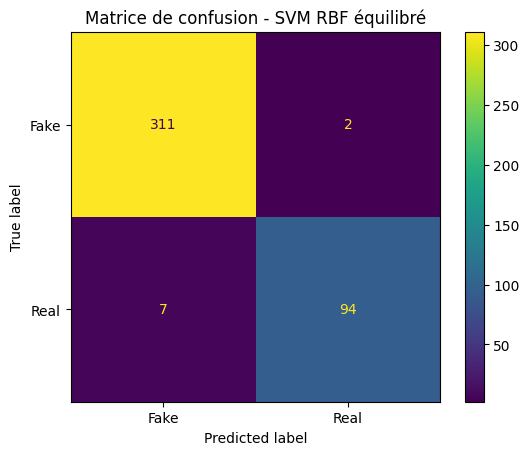

Erreurs Real classées Fake : 7
Erreurs Fake classées Real : 2


In [414]:

# 23) MEILLEUR MODÈLE : RAPPORT + MATRICE DE CONFUSION


best_model_name = results_df.iloc[0]['Modèle']
best_model = trained_models[best_model_name]
y_val_pred = best_model.predict(C_val)

print('Meilleur modèle :', best_model_name)
print('Nombre d\'axes ACP utilisés :', n_selected)
print('Accuracy validation :', accuracy_score(y_val, y_val_pred))
print('Balanced accuracy :', balanced_accuracy_score(y_val, y_val_pred))
print('F1-score macro :', f1_score(y_val, y_val_pred, average='macro'))
print('\nClassification report :')
print(classification_report(y_val, y_val_pred, target_names=[CLASS_NAMES[0], CLASS_NAMES[1]]))

cm = confusion_matrix(y_val, y_val_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[CLASS_NAMES[0], CLASS_NAMES[1]])
disp.plot(values_format='d')
plt.title(f'Matrice de confusion - {best_model_name}')
plt.show()

# Analyse ciblée du biais Real -> Fake
nb_real_to_fake = int(((y_val == 1) & (y_val_pred == 0)).sum())
nb_fake_to_real = int(((y_val == 0) & (y_val_pred == 1)).sum())
print('Erreurs Real classées Fake :', nb_real_to_fake)
print('Erreurs Fake classées Real :', nb_fake_to_real)

## 23 bis) Calibration du seuil Real/Fake et analyse des erreurs

Cette section répond au problème observé pendant les tests externes : certaines images réellement humaines sont prédites **Fake**.  
La correction reste dans le cadre ACP : on ne change pas le pipeline **X → Z → ACP → SVM**, mais on calibre le seuil de décision à partir de la validation.

Au lieu d'utiliser automatiquement le seuil 0,50 pour la classe Real, on teste plusieurs seuils et on retient celui qui donne le meilleur compromis entre :

- balanced accuracy ;
- rappel de la classe Real ;
- rappel de la classe Fake.

Ainsi, si le modèle donne par exemple Real = 36 % et Fake = 64 %, on peut éviter de conclure trop vite Fake lorsque la validation montre que le seuil Real optimal est plus bas.

In [415]:
from sklearn.metrics import recall_score

# 23 bis-A) CALIBRATION DU SEUIL REAL / FAKE APRÈS ACP


REAL_LABEL = 1
FAKE_LABEL = 0

if not hasattr(best_model, 'predict_proba'):
    print("Le meilleur modèle ne fournit pas predict_proba. Seuil par défaut utilisé.")
    BEST_REAL_THRESHOLD = BEST_REAL_THRESHOLD_FALLBACK
    y_val_pred_calibrated = y_val_pred.copy()
    threshold_results_df = pd.DataFrame()
else:
    val_proba = best_model.predict_proba(C_val)
    model_classes = list(best_model.classes_)
    print("Ordre des classes dans le modèle :", model_classes)

    real_idx = model_classes.index(REAL_LABEL)
    fake_idx = model_classes.index(FAKE_LABEL)
    proba_real_val = val_proba[:, real_idx]
    proba_fake_val = val_proba[:, fake_idx]

    thresholds = np.arange(REAL_THRESHOLD_MIN, REAL_THRESHOLD_MAX + 1e-9, REAL_THRESHOLD_STEP)
    rows = []

    for t in thresholds:
        # Si proba Real dépasse le seuil calibré -> Real, sinon Fake.
        pred_t = np.where(proba_real_val >= t, REAL_LABEL, FAKE_LABEL)
        bal_acc = balanced_accuracy_score(y_val, pred_t)
        real_recall = recall_score(y_val, pred_t, pos_label=REAL_LABEL, zero_division=0)
        fake_recall = recall_score(y_val, pred_t, pos_label=FAKE_LABEL, zero_division=0)
        real_to_fake = int(((y_val == REAL_LABEL) & (pred_t == FAKE_LABEL)).sum())
        fake_to_real = int(((y_val == FAKE_LABEL) & (pred_t == REAL_LABEL)).sum())

        # Score de choix : équilibré, avec légère priorité au rappel Real.
        score = bal_acc + REAL_RECALL_PRIORITY * real_recall
        rows.append({
            "Seuil Real": float(t),
            "Balanced accuracy": bal_acc,
            "Recall Real": real_recall,
            "Recall Fake": fake_recall,
            "Real prédits Fake": real_to_fake,
            "Fake prédits Real": fake_to_real,
            "Score choix": score,
        })

    threshold_results_df = pd.DataFrame(rows).sort_values(
        ["Score choix", "Balanced accuracy", "Recall Fake"],
        ascending=[False, False, False]
    )
    display(threshold_results_df.head(12))

    if CALIBRATE_REAL_THRESHOLD and len(threshold_results_df) > 0:
        BEST_REAL_THRESHOLD = float(threshold_results_df.iloc[0]["Seuil Real"])
    else:
        BEST_REAL_THRESHOLD = 0.50

    y_val_pred_calibrated = np.where(proba_real_val >= BEST_REAL_THRESHOLD, REAL_LABEL, FAKE_LABEL)

    print("Seuil Real retenu =", BEST_REAL_THRESHOLD)
    print("Ancien seuil implicite = 0.50")
    print("Balanced accuracy calibrée :", balanced_accuracy_score(y_val, y_val_pred_calibrated))
    print("Rappel Real calibré :", recall_score(y_val, y_val_pred_calibrated, pos_label=REAL_LABEL, zero_division=0))
    print("Rappel Fake calibré :", recall_score(y_val, y_val_pred_calibrated, pos_label=FAKE_LABEL, zero_division=0))

    # Tableau comparatif avant / après calibration
    comparison_threshold_df = pd.DataFrame([
        {
            "Décision": "Standard model.predict()",
            "Balanced accuracy": balanced_accuracy_score(y_val, y_val_pred),
            "Recall Real": recall_score(y_val, y_val_pred, pos_label=REAL_LABEL, zero_division=0),
            "Recall Fake": recall_score(y_val, y_val_pred, pos_label=FAKE_LABEL, zero_division=0),
            "Real prédits Fake": int(((y_val == REAL_LABEL) & (y_val_pred == FAKE_LABEL)).sum()),
            "Fake prédits Real": int(((y_val == FAKE_LABEL) & (y_val_pred == REAL_LABEL)).sum()),
        },
        {
            "Décision": f"Seuil Real calibré = {BEST_REAL_THRESHOLD:.2f}",
            "Balanced accuracy": balanced_accuracy_score(y_val, y_val_pred_calibrated),
            "Recall Real": recall_score(y_val, y_val_pred_calibrated, pos_label=REAL_LABEL, zero_division=0),
            "Recall Fake": recall_score(y_val, y_val_pred_calibrated, pos_label=FAKE_LABEL, zero_division=0),
            "Real prédits Fake": int(((y_val == REAL_LABEL) & (y_val_pred_calibrated == FAKE_LABEL)).sum()),
            "Fake prédits Real": int(((y_val == FAKE_LABEL) & (y_val_pred_calibrated == REAL_LABEL)).sum()),
        }
    ])
    display(comparison_threshold_df)

    try:
        threshold_results_df.to_csv(OUTPUT_DIR / "17_calibration_seuil_real.csv", index=False)
        comparison_threshold_df.to_csv(OUTPUT_DIR / "18_comparaison_avant_apres_calibration.csv", index=False)
    except Exception:
        pass

Ordre des classes dans le modèle : [np.int64(0), np.int64(1)]


,Seuil Real,Balanced accuracy,Recall Real,Recall Fake,Real prédits Fake,Fake prédits Real,Score choix
0,0.20,0.968858,0.950495,0.987220,5,4,1.111432
1,0.21,0.965505,0.940594,0.990415,6,3,1.106594
2,0.22,0.965505,0.940594,0.990415,6,3,1.106594
3,0.23,0.965505,0.940594,0.990415,6,3,1.106594
4,0.24,0.965505,0.940594,0.990415,6,3,1.106594
5,0.25,0.965505,0.940594,0.990415,6,3,1.106594
6,0.26,0.965505,0.940594,0.990415,6,3,1.106594
7,0.27,0.965505,0.940594,0.990415,6,3,1.106594
8,0.28,0.965505,0.940594,0.990415,6,3,1.106594
9,0.29,0.965505,0.940594,0.990415,6,3,1.106594


Seuil Real retenu = 0.2
Ancien seuil implicite = 0.50
Balanced accuracy calibrée : 0.9688577483946477
Rappel Real calibré : 0.9504950495049505
Rappel Fake calibré : 0.987220447284345


,Décision,Balanced accuracy,Recall Real,Recall Fake,Real prédits Fake,Fake prédits Real
0,Standard model.predict(),0.962152,0.930693,0.99361,7,2
1,Seuil Real calibré = 0.20,0.968858,0.950495,0.98722,5,4


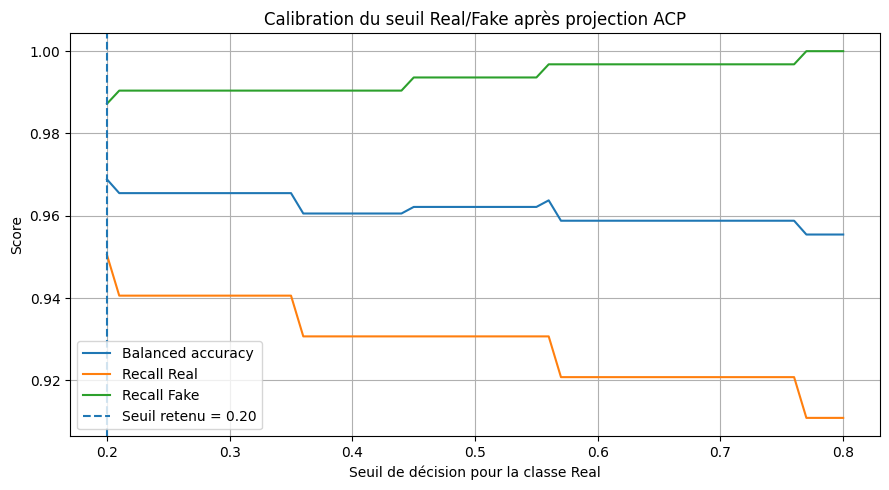

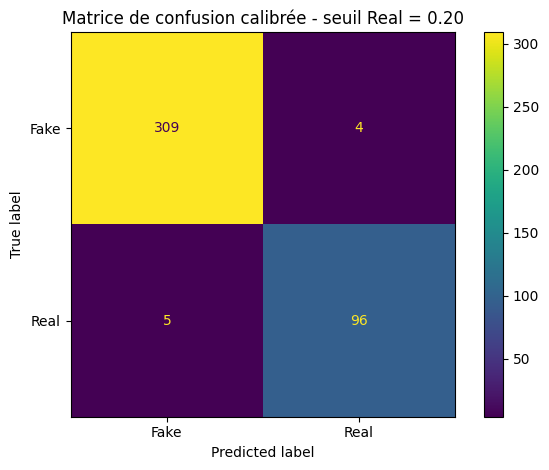

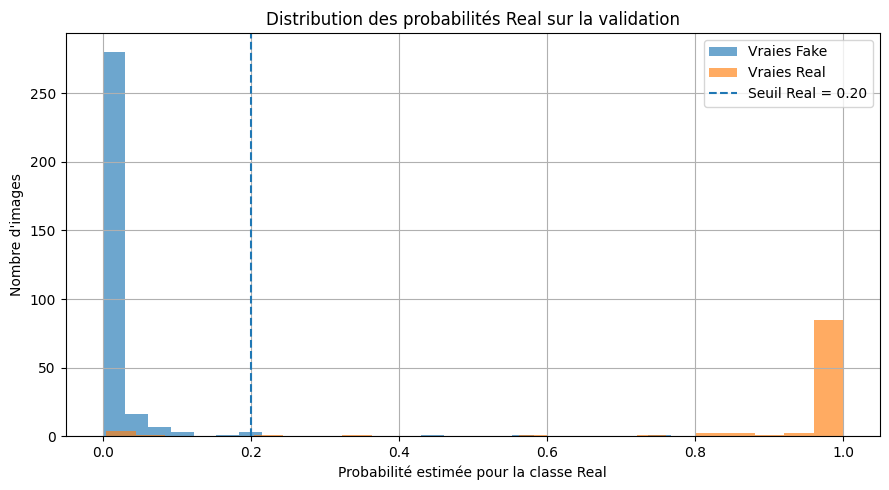

In [416]:

# 23 bis-B) GRAPHES DE CALIBRATION ET MATRICE DE CONFUSION CALIBRÉE


if 'threshold_results_df' in globals() and len(threshold_results_df) > 0:
    df_thr_plot = threshold_results_df.sort_values("Seuil Real")

    plt.figure(figsize=(9, 5))
    plt.plot(df_thr_plot["Seuil Real"], df_thr_plot["Balanced accuracy"], label="Balanced accuracy")
    plt.plot(df_thr_plot["Seuil Real"], df_thr_plot["Recall Real"], label="Recall Real")
    plt.plot(df_thr_plot["Seuil Real"], df_thr_plot["Recall Fake"], label="Recall Fake")
    plt.axvline(BEST_REAL_THRESHOLD, linestyle="--", label=f"Seuil retenu = {BEST_REAL_THRESHOLD:.2f}")
    plt.xlabel("Seuil de décision pour la classe Real")
    plt.ylabel("Score")
    plt.title("Calibration du seuil Real/Fake après projection ACP")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    try:
        plt.savefig(OUTPUT_DIR / "19_courbe_calibration_seuil_real.png", dpi=200, bbox_inches="tight")
    except Exception:
        pass
    plt.show()

    cm_cal = confusion_matrix(y_val, y_val_pred_calibrated, labels=[FAKE_LABEL, REAL_LABEL])
    ConfusionMatrixDisplay(cm_cal, display_labels=[CLASS_NAMES[FAKE_LABEL], CLASS_NAMES[REAL_LABEL]]).plot(values_format='d')
    plt.title(f"Matrice de confusion calibrée - seuil Real = {BEST_REAL_THRESHOLD:.2f}")
    plt.tight_layout()
    try:
        plt.savefig(OUTPUT_DIR / "20_matrice_confusion_calibree.png", dpi=200, bbox_inches="tight")
    except Exception:
        pass
    plt.show()

    plt.figure(figsize=(9, 5))
    plt.hist(proba_real_val[y_val == FAKE_LABEL], bins=25, alpha=0.65, label="Vraies Fake")
    plt.hist(proba_real_val[y_val == REAL_LABEL], bins=25, alpha=0.65, label="Vraies Real")
    plt.axvline(BEST_REAL_THRESHOLD, linestyle="--", label=f"Seuil Real = {BEST_REAL_THRESHOLD:.2f}")
    plt.xlabel("Probabilité estimée pour la classe Real")
    plt.ylabel("Nombre d'images")
    plt.title("Distribution des probabilités Real sur la validation")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    try:
        plt.savefig(OUTPUT_DIR / "21_histogramme_probabilites_real.png", dpi=200, bbox_inches="tight")
    except Exception:
        pass
    plt.show()
else:
    print("Calibration non disponible : modèle sans probabilités ou cellule précédente non exécutée.")


Nombre d'erreurs après calibration : 9 / 414


,Image,Vraie classe,Classe prédite calibrée,F1,F2,Proba Real
0,5_2.avi_100_real.jpg,Real,Fake,17.641434,-0.339061,0.005123
1,11_HR_1.avi_200_real.jpg,Real,Fake,-25.275747,-18.927664,0.006443
2,20_HR_2.avi_125_fake.jpg,Fake,Real,-49.018467,-21.487619,0.767317
3,7_4.avi_125_fake.jpg,Fake,Real,44.646469,88.254333,0.554265
4,10_1.avi_75_real.jpg,Real,Fake,2.194314,-35.161957,0.035860
5,13_1.avi_150_real.jpg,Real,Fake,24.980825,9.106751,0.024168
6,11_HR_1.avi_325_real.jpg,Real,Fake,-26.999903,-18.095831,0.067599
7,20_HR_2.avi_75_fake.jpg,Fake,Real,-50.948784,-23.709061,0.201312
8,13_6.avi_150_fake.jpg,Fake,Real,9.869651,-12.023799,0.446539


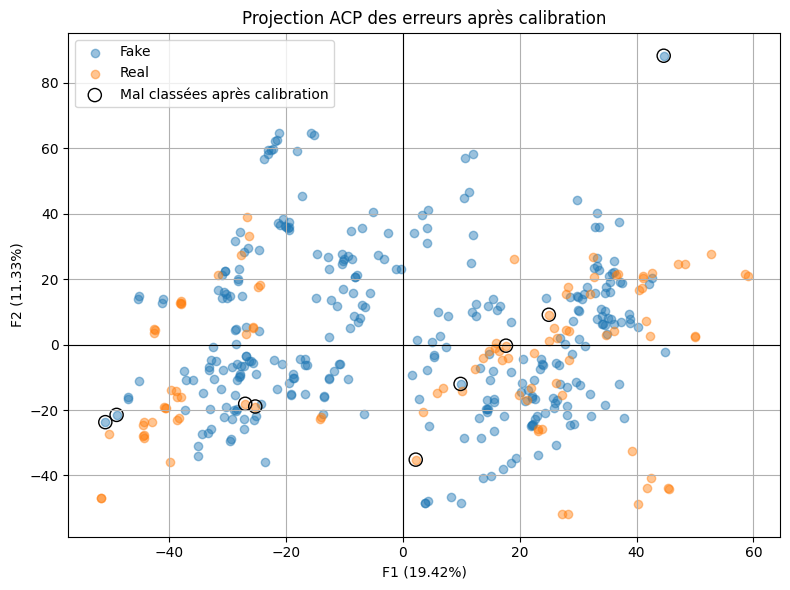

In [417]:

# 23 bis-C) ERREURS APRÈS CALIBRATION DANS LE PLAN ACP F1-F2


if 'y_val_pred_calibrated' in globals():
    errors_cal = np.where(y_val != y_val_pred_calibrated)[0]
    errors_cal_df = pd.DataFrame({
        "Image": [paths_val[i].name for i in errors_cal],
        "Vraie classe": pd.Series(y_val[errors_cal]).map(CLASS_NAMES).values,
        "Classe prédite calibrée": pd.Series(y_val_pred_calibrated[errors_cal]).map(CLASS_NAMES).values,
        "F1": C_val_full[errors_cal, 0],
        "F2": C_val_full[errors_cal, 1],
        "Proba Real": proba_real_val[errors_cal] if 'proba_real_val' in globals() else np.nan,
    })
    print("Nombre d'erreurs après calibration :", len(errors_cal), "/", len(y_val))
    display(errors_cal_df.head(25))

    plt.figure(figsize=(8, 6))
    for lab in np.unique(y_val):
        idx = (y_val == lab)
        plt.scatter(C_val_full[idx, 0], C_val_full[idx, 1], label=CLASS_NAMES[int(lab)], alpha=0.45)
    if len(errors_cal) > 0:
        plt.scatter(C_val_full[errors_cal, 0], C_val_full[errors_cal, 1],
                    facecolors='none', edgecolors='black', s=90, label='Mal classées après calibration')
    plt.axhline(0, color='black', linewidth=0.8)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.xlabel(f"F1 ({inertia_ratio[0]*100:.2f}%)")
    plt.ylabel(f"F2 ({inertia_ratio[1]*100:.2f}%)")
    plt.title("Projection ACP des erreurs après calibration")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    try:
        plt.savefig(OUTPUT_DIR / "22_erreurs_calibrees_plan_F1_F2.png", dpi=200, bbox_inches='tight')
        errors_cal_df.to_csv(OUTPUT_DIR / "23_erreurs_calibrees.csv", index=False)
    except Exception:
        pass
    plt.show()
else:
    print("Exécute la calibration du seuil avant cette cellule.")


--- Test officiel : décision standard ---
Accuracy test officiel : 0.8063157894736842
Balanced accuracy test officiel : 0.6725814401577273
              precision    recall  f1-score   support

        Fake       0.81      0.97      0.88       346
        Real       0.80      0.38      0.52       129

    accuracy                           0.81       475
   macro avg       0.81      0.67      0.70       475
weighted avg       0.81      0.81      0.78       475



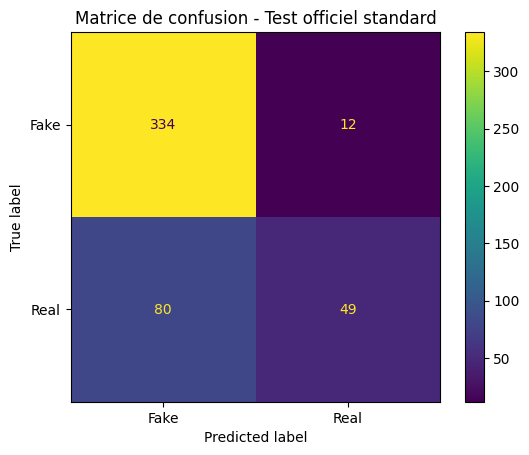


--- Test officiel : décision calibrée ---
Seuil Real utilisé : 0.2
Accuracy test calibrée : 0.8147368421052632
Balanced accuracy test calibrée : 0.7099632567101313
              precision    recall  f1-score   support

        Fake       0.83      0.94      0.88       346
        Real       0.75      0.48      0.58       129

    accuracy                           0.81       475
   macro avg       0.79      0.71      0.73       475
weighted avg       0.81      0.81      0.80       475



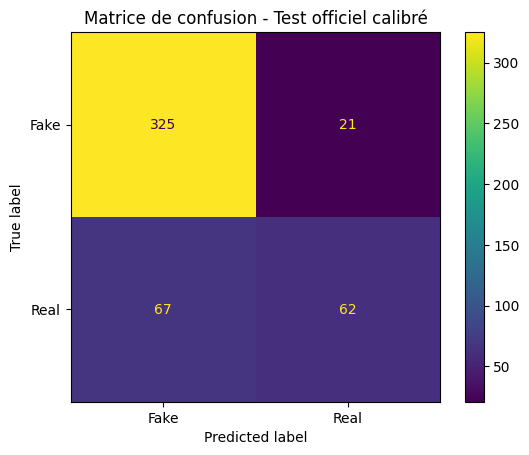

In [418]:

# 24) ÉVALUATION SUR TEST OFFICIEL SI LABELS DISPONIBLES


if X_test_raw.shape[0] > 0:
    Z_test = scaler_model.transform(X_test_raw)
    C_test_full = pca_full.transform(Z_test)
    C_test = C_test_full[:, :n_selected]

    if y_test_raw is not None and len(y_test_raw) == X_test_raw.shape[0] and len(np.unique(y_test_raw)) >= 2:
        y_test_pred = best_model.predict(C_test)
        print('--- Test officiel : décision standard ---')
        print('Accuracy test officiel :', accuracy_score(y_test_raw, y_test_pred))
        print('Balanced accuracy test officiel :', balanced_accuracy_score(y_test_raw, y_test_pred))
        print(classification_report(y_test_raw, y_test_pred, target_names=[CLASS_NAMES[0], CLASS_NAMES[1]]))
        cm = confusion_matrix(y_test_raw, y_test_pred, labels=[0, 1])
        ConfusionMatrixDisplay(cm, display_labels=[CLASS_NAMES[0], CLASS_NAMES[1]]).plot(values_format='d')
        plt.title('Matrice de confusion - Test officiel standard')
        plt.show()

        if hasattr(best_model, 'predict_proba') and 'BEST_REAL_THRESHOLD' in globals():
            print('\n--- Test officiel : décision calibrée ---')
            test_proba = best_model.predict_proba(C_test)
            labels_order = list(best_model.classes_)
            real_idx_test = labels_order.index(REAL_LABEL)
            proba_real_test = test_proba[:, real_idx_test]
            y_test_pred_cal = np.where(proba_real_test >= BEST_REAL_THRESHOLD, REAL_LABEL, FAKE_LABEL)

            print('Seuil Real utilisé :', BEST_REAL_THRESHOLD)
            print('Accuracy test calibrée :', accuracy_score(y_test_raw, y_test_pred_cal))
            print('Balanced accuracy test calibrée :', balanced_accuracy_score(y_test_raw, y_test_pred_cal))
            print(classification_report(y_test_raw, y_test_pred_cal, target_names=[CLASS_NAMES[0], CLASS_NAMES[1]]))
            cm_cal = confusion_matrix(y_test_raw, y_test_pred_cal, labels=[0, 1])
            ConfusionMatrixDisplay(cm_cal, display_labels=[CLASS_NAMES[0], CLASS_NAMES[1]]).plot(values_format='d')
            plt.title('Matrice de confusion - Test officiel calibré')
            try:
                plt.savefig(OUTPUT_DIR / '24_matrice_confusion_test_calibree.png', dpi=200, bbox_inches='tight')
            except Exception:
                pass
            plt.show()
    else:
        y_test_pred = best_model.predict(C_test)
        pred_table = pd.DataFrame({
            'Image': [p.name for p in test_paths_kept],
            'Prediction': pd.Series(y_test_pred).map(CLASS_NAMES)
        })
        display(pred_table.head(20))
else:
    print('Aucune image de test trouvée.')


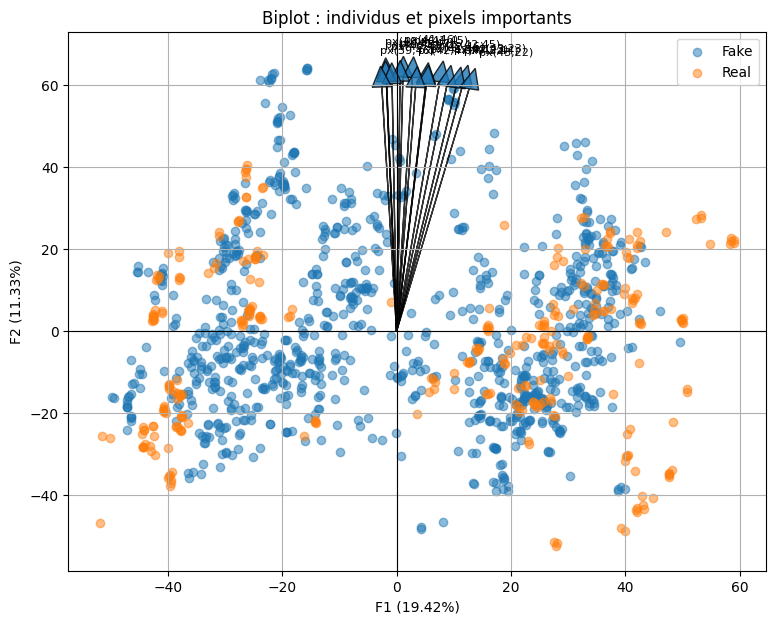

In [419]:

# 25) BIPLOT : INDIVIDUS + VARIABLES IMPORTANTES

def plot_biplot(C_data, y_data, var_coords, top_idx, scale=4.0, title='Biplot ACP F1-F2'):
    plt.figure(figsize=(9, 7))
    for lab in np.unique(y_data):
        idx = (y_data == lab)
        plt.scatter(C_data[idx, 0], C_data[idx, 1], alpha=0.5, label=CLASS_NAMES[int(lab)])

    # Variables : on les met à une échelle visible
    sx = np.std(C_data[:, 0]) * scale
    sy = np.std(C_data[:, 1]) * scale
    for idx in top_idx[:15]:
        x = var_coords[idx, 0] * sx
        y = var_coords[idx, 1] * sy
        plt.arrow(0, 0, x, y, head_width=0.03*sx, length_includes_head=True, alpha=0.8)
        plt.text(x*1.05, y*1.05, var_labels[idx], fontsize=8)

    plt.axhline(0, color='black', linewidth=0.8)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.xlabel(f'F1 ({inertia_ratio[0]*100:.2f}%)')
    plt.ylabel(f'F2 ({inertia_ratio[1]*100:.2f}%)')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_biplot(C_tr_full, y_tr, var_coords, top_idx, title='Biplot : individus et pixels importants')


In [420]:
# 25 bis-A) DOSSIER D'EXPORT DES RÉSULTATS ACP


from pathlib import Path

OUTPUT_DIR = Path("ACP_RESULTATS_MAIL_BAROUD")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Dossier de sortie :", OUTPUT_DIR.resolve())

# Export du tableau d'inertie
acp_table_export = acp_table.copy()
acp_table_export.to_csv(OUTPUT_DIR / "01_table_valeurs_propres_inertie.csv", index=False)

# Export projections / cos² / contributions
proj_train_table.to_csv(OUTPUT_DIR / "02_projection_individus_axes.csv", index=False)
cos2_ind_train.to_csv(OUTPUT_DIR / "03_cos2_individus.csv", index=False)
contrib_ind_train.to_csv(OUTPUT_DIR / "04_contributions_individus.csv", index=False)
mal_represented.to_csv(OUTPUT_DIR / "05_individus_mal_representes.csv", index=False)
var_contrib_table.to_csv(OUTPUT_DIR / "06_contributions_variables_pixels.csv", index=False)

print("Exports CSV créés :")
for p in sorted(OUTPUT_DIR.glob("*.csv")):
    print("-", p.name)


Dossier de sortie : C:\Users\MICROSOFTPRO DZ\OneDrive\Desktop\MIV S2\analyse de donnee\PROJET\ACP_RESULTATS_MAIL_BAROUD
Exports CSV créés :
- 00_checklist_conformite_mail.csv
- 00_erreurs_validation.csv
- 01_table_valeurs_propres_inertie.csv
- 02_projection_individus_axes.csv
- 03_cos2_individus.csv
- 04_contributions_individus.csv
- 05_individus_mal_representes.csv
- 06_contributions_variables_pixels.csv
- 07_verification_vecteurs_propres.csv
- 08_distances_individus_centre.csv
- 09_top_contributions_individus_F1.csv
- 09_top_contributions_individus_F2.csv
- 09_top_contributions_individus_F3.csv
- 10_centres_classes_plan_factoriel.csv
- 11_mal_representes_F1.csv
- 11_mal_representes_F2.csv
- 11_mal_representes_F3.csv
- 12_matrice_correlation_top_pixels.csv
- 17_calibration_seuil_real.csv
- 18_comparaison_avant_apres_calibration.csv
- 23_erreurs_calibrees.csv


## 25 bis-0) Analyse ACP des erreurs de classification

Cette partie répond directement au mail : on ne se limite pas à dire Real/Fake, on observe où les erreurs se placent dans le plan factoriel. Les erreurs sont entourées sur le graphe des individus.

Nombre d'erreurs validation : 9 / 414


,Image,Vraie classe,Classe prédite,F1,F2
0,5_2.avi_100_real.jpg,Real,Fake,17.641434,-0.339061
1,19_HR_1.avi_175_real.jpg,Real,Fake,-38.056087,-16.005108
2,20_2.avi_125_real.jpg,Real,Fake,19.899029,-15.466995
3,11_HR_1.avi_200_real.jpg,Real,Fake,-25.275747,-18.927664
4,20_HR_2.avi_125_fake.jpg,Fake,Real,-49.018467,-21.487619
5,7_4.avi_125_fake.jpg,Fake,Real,44.646469,88.254333
6,10_1.avi_75_real.jpg,Real,Fake,2.194314,-35.161957
7,13_1.avi_150_real.jpg,Real,Fake,24.980825,9.106751
8,11_HR_1.avi_325_real.jpg,Real,Fake,-26.999903,-18.095831


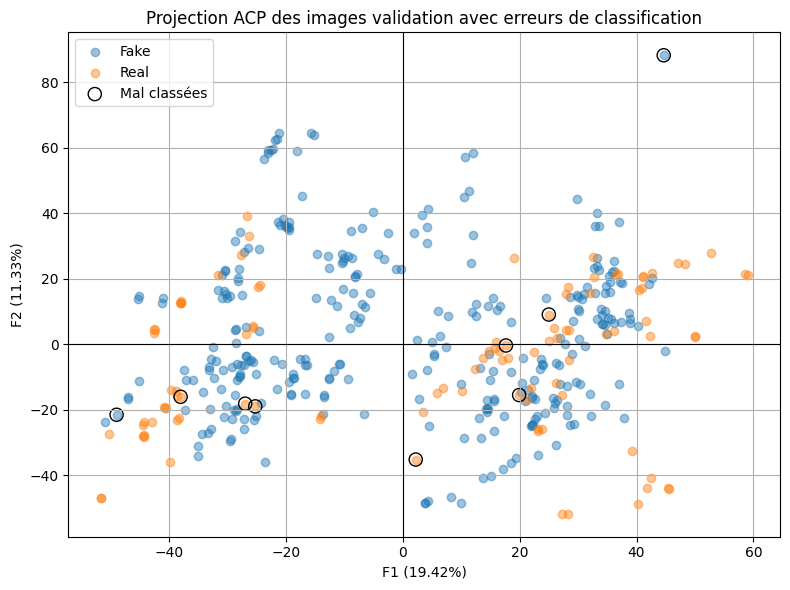

In [421]:

# 25 bis-0) ERREURS DE CLASSIFICATION DANS LE PLAN ACP F1-F2


if 'y_val_pred' in globals():
    errors_val = np.where(y_val != y_val_pred)[0]
    errors_val_df = pd.DataFrame({
        'Image': [paths_val[i].name for i in errors_val],
        'Vraie classe': pd.Series(y_val[errors_val]).map(CLASS_NAMES).values,
        'Classe prédite': pd.Series(y_val_pred[errors_val]).map(CLASS_NAMES).values,
        'F1': C_val_full[errors_val, 0],
        'F2': C_val_full[errors_val, 1],
    })
    print('Nombre d\'erreurs validation :', len(errors_val), '/', len(y_val))
    display(errors_val_df.head(20))

    plt.figure(figsize=(8, 6))
    for lab in np.unique(y_val):
        idx = (y_val == lab)
        plt.scatter(C_val_full[idx, 0], C_val_full[idx, 1], label=CLASS_NAMES[int(lab)], alpha=0.45)
    if len(errors_val) > 0:
        plt.scatter(C_val_full[errors_val, 0], C_val_full[errors_val, 1],
                    facecolors='none', edgecolors='black', s=90, label='Mal classées')
    plt.axhline(0, color='black', linewidth=0.8)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.xlabel(f'F1 ({inertia_ratio[0]*100:.2f}%)')
    plt.ylabel(f'F2 ({inertia_ratio[1]*100:.2f}%)')
    plt.title('Projection ACP des images validation avec erreurs de classification')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    try:
        plt.savefig(OUTPUT_DIR / '00_erreurs_validation_plan_F1_F2.png', dpi=200, bbox_inches='tight')
        errors_val_df.to_csv(OUTPUT_DIR / '00_erreurs_validation.csv', index=False)
    except Exception:
        pass
    plt.show()
else:
    print('Exécute d\'abord la cellule du meilleur modèle pour obtenir y_val_pred.')

In [422]:

# 25 bis-B) VÉRIFICATION D'UN AXE PROPRE : R.u = lambda.u


m_train = Z_tr.shape[0]
n_check = min(3, pca_full.components_.shape[0])

verification_rows = []
for k in range(n_check):
    u = pca_full.components_[k]  # vecteur propre / axe factoriel
    # sklearn explained_variance_ utilise 1/(m-1)
    Ru = (Z_tr.T @ (Z_tr @ u)) / (m_train - 1)
    lambda_u = pca_full.explained_variance_[k] * u
    erreur = np.linalg.norm(Ru - lambda_u)
    rel_erreur = erreur / (np.linalg.norm(lambda_u) + 1e-12)
    verification_rows.append({
        "Axe": f"F{k+1}",
        "lambda": pca_full.explained_variance_[k],
        "||R.u - lambda.u||": erreur,
        "Erreur relative": rel_erreur,
        "Validation": "OK" if rel_erreur < 1e-5 else "Approx."
    })

verif_df = pd.DataFrame(verification_rows)
display(verif_df)
verif_df.to_csv(OUTPUT_DIR / "07_verification_vecteurs_propres.csv", index=False)


,Axe,lambda,||R.u - lambda.u||,Erreur relative,Validation
0,F1,796.053589,0.001176,1.477722e-06,OK
1,F2,464.367340,0.000538,1.158554e-06,OK
2,F3,281.151489,0.000220,7.827891e-07,OK


In [423]:

# 25 bis-C) DISTANCE DES INDIVIDUS AU CENTRE DU NUAGE


dist2_ind = np.sum(Z_tr**2, axis=1)
dist_ind_table = pd.DataFrame({
    "Image": [p.name for p in paths_tr],
    "Classe": pd.Series(y_tr).map(CLASS_NAMES).values,
    "Distance² au centre": dist2_ind,
    "F1": C_tr_full[:, 0],
    "F2": C_tr_full[:, 1],
})
dist_ind_table = dist_ind_table.sort_values("Distance² au centre", ascending=False)

print("Somme des distances² au centre =", dist2_ind.sum())
print("Moyenne des distances² au centre =", dist2_ind.mean())
display(dist_ind_table.head(15))

dist_ind_table.to_csv(OUTPUT_DIR / "08_distances_individus_centre.csv", index=False)


Somme des distances² au centre = 5083136.0
Moyenne des distances² au centre = 4096.0


,Image,Classe,Distance² au centre,F1,F2
60,3_1.avi_125_real.jpg,Real,7929.875488,41.723217,-34.122459
157,8_HR_4.avi_75_fake.jpg,Fake,7728.731934,-15.734735,64.339302
1077,8_HR_4.avi_125_fake.jpg,Fake,7723.796875,-15.638109,63.640602
252,7_HR_4.avi_50_fake.jpg,Fake,7680.756836,-21.427788,63.074539
863,8_HR_4.avi_100_fake.jpg,Fake,7674.463379,-15.836563,63.743290
97,2_HR_4.avi_75_fake.jpg,Fake,7575.773926,-39.120686,8.856297
814,1_HR_4.avi_25_fake.jpg,Fake,7551.878906,-21.824638,62.716587
1130,8_HR_4.avi_25_fake.jpg,Fake,7492.745605,-15.683173,64.117943
615,9_HR_4.avi_75_fake.jpg,Fake,7480.906250,-18.651627,52.686474
590,8_1.avi_25_real.jpg,Real,7451.960449,50.055332,1.891066


In [424]:

# 25 bis-D) TABLEAUX DES PLUS FORTES CONTRIBUTIONS PAR AXE


n_axes_show = min(3, n_selected)

for ax in range(n_axes_show):
    col = f"Contribution F{ax+1} (%)"
    top_contrib_ax = contrib_ind_train.sort_values(col, ascending=False).head(10)
    print(f"\nTop 10 individus contributeurs à l'axe F{ax+1}")
    display(top_contrib_ax[["Image", "Classe", col]])
    top_contrib_ax.to_csv(OUTPUT_DIR / f"09_top_contributions_individus_F{ax+1}.csv", index=False)

# Centre des classes dans le plan factoriel : utile pour interpréter F1/F2
centres_classes = pd.DataFrame({
    "Classe": pd.Series(y_tr).map(CLASS_NAMES).values,
    "F1": C_tr_full[:, 0],
    "F2": C_tr_full[:, 1],
    "F3": C_tr_full[:, 2] if n_selected >= 3 else np.nan
}).groupby("Classe").mean()

print("\nCentres moyens des classes dans l'espace factoriel :")
display(centres_classes)
centres_classes.to_csv(OUTPUT_DIR / "10_centres_classes_plan_factoriel.csv")



Top 10 individus contributeurs à l'axe F1


,Image,Classe,Contribution F1 (%)
353,6_2.avi_75_real.jpg,Real,0.353284
624,6_2.avi_25_real.jpg,Real,0.352084
1191,6_2.avi_100_real.jpg,Real,0.347616
155,6_2.avi_175_real.jpg,Real,0.347413
251,6_2.avi_200_real.jpg,Real,0.344030
32,6_2.avi_150_real.jpg,Real,0.304411
816,4_2.avi_25_real.jpg,Real,0.287341
655,4_2.avi_50_real.jpg,Real,0.286291
667,4_2.avi_100_real.jpg,Real,0.277909
1115,4_HR_1.avi_200_real.jpg,Real,0.272369



Top 10 individus contributeurs à l'axe F2


,Image,Classe,Contribution F2 (%)
157,8_HR_4.avi_75_fake.jpg,Fake,0.718902
1130,8_HR_4.avi_25_fake.jpg,Fake,0.713963
863,8_HR_4.avi_100_fake.jpg,Fake,0.705644
1077,8_HR_4.avi_125_fake.jpg,Fake,0.703372
252,7_HR_4.avi_50_fake.jpg,Fake,0.690916
814,1_HR_4.avi_25_fake.jpg,Fake,0.683096
884,7_HR_4.avi_100_fake.jpg,Fake,0.662043
305,7_HR_4.avi_125_fake.jpg,Fake,0.658789
41,1_HR_4.avi_175_fake.jpg,Fake,0.650575
529,1_HR_4.avi_50_fake.jpg,Fake,0.650292



Top 10 individus contributeurs à l'axe F3


,Image,Classe,Contribution F3 (%)
748,5_3.avi_125_fake.jpg,Fake,0.451480
550,3_HR_1.avi_175_real.jpg,Real,0.435268
891,2_7.avi_150_fake.jpg,Fake,0.433403
1150,13_7.avi_25_fake.jpg,Fake,0.414853
200,2_7.avi_100_fake.jpg,Fake,0.413395
295,2_7.avi_175_fake.jpg,Fake,0.412140
997,3_HR_4.avi_175_fake.jpg,Fake,0.408397
66,13_HR_1.avi_125_real.jpg,Real,0.406048
364,13_HR_1.avi_75_real.jpg,Real,0.397713
385,3_HR_1.avi_125_real.jpg,Real,0.390512



Centres moyens des classes dans l'espace factoriel :


,F1,F2,F3
Classe,,,
Fake,-0.930943,1.369807,0.521447
Real,2.881931,-4.240524,-1.614249


In [425]:

# 25 bis-E) INDIVIDUS MAL REPRÉSENTÉS AXE PAR AXE AVEC SIGNE


for ax in range(n_axes_show):
    qcol = f"Qualité axe F{ax+1}"
    tmp = cos2_ind_train.copy()
    tmp[f"Coordonnée F{ax+1}"] = C_tr_full[:, ax]
    tmp[f"Signe F{ax+1}"] = np.where(C_tr_full[:, ax] >= 0, "+", "-")
    tmp = tmp.sort_values(qcol).head(10)
    print(f"\n10 individus les moins bien représentés sur F{ax+1}")
    display(tmp[["Image", "Classe", qcol, f"Coordonnée F{ax+1}", f"Signe F{ax+1}"]])
    tmp.to_csv(OUTPUT_DIR / f"11_mal_representes_F{ax+1}.csv", index=False)



10 individus les moins bien représentés sur F1


,Image,Classe,Qualité axe F1,Coordonnée F1,Signe F1
15,11_6.avi_75_fake.jpg,Fake,0.000002,0.049656,+
692,11_6.avi_50_fake.jpg,Fake,0.000002,0.050519,+
168,3_4.avi_175_fake.jpg,Fake,0.000007,-0.107281,-
650,7_8.avi_75_fake.jpg,Fake,0.000013,-0.254716,-
544,7_8.avi_50_fake.jpg,Fake,0.000023,0.356429,+
460,13_8.avi_75_fake.jpg,Fake,0.000029,0.308662,+
94,7_8.avi_100_fake.jpg,Fake,0.000050,0.514903,+
808,11_8.avi_75_fake.jpg,Fake,0.000093,-0.508117,-
993,5_HR_2.avi_100_fake.jpg,Fake,0.000102,0.704330,+
1136,18_3.avi_50_fake.jpg,Fake,0.000112,-0.468630,-



10 individus les moins bien représentés sur F2


,Image,Classe,Qualité axe F2,Coordonnée F2,Signe F2
1193,10_2.avi_125_real.jpg,Real,1.392566e-07,-0.019114,-
307,8_HR_2.avi_200_fake.jpg,Fake,8.769319e-07,-0.063937,-
781,16_1.avi_150_real.jpg,Real,9.583459e-07,-0.071029,-
757,18_5.avi_75_fake.jpg,Fake,3.635711e-06,-0.093671,-
780,1_3.avi_50_fake.jpg,Fake,4.263170e-06,0.134211,+
657,13_HR_3.avi_125_fake.jpg,Fake,8.195889e-06,0.179084,+
622,2_3.avi_50_fake.jpg,Fake,1.596229e-05,-0.310443,-
565,14_8.avi_75_fake.jpg,Fake,1.676543e-05,0.192953,+
493,1_4.avi_150_fake.jpg,Fake,2.080346e-05,0.226875,+
404,15_HR_2.avi_200_fake.jpg,Fake,3.942093e-05,-0.360886,-



10 individus les moins bien représentés sur F3


,Image,Classe,Qualité axe F3,Coordonnée F3,Signe F3
687,4_7.avi_125_fake.jpg,Fake,8.163493e-09,-0.004668,-
689,7_1.avi_125_real.jpg,Real,9.575280e-08,-0.022343,-
1118,4_7.avi_25_fake.jpg,Fake,1.144567e-06,0.052688,+
388,4_HR_2.avi_50_fake.jpg,Fake,1.398164e-06,0.076817,+
445,11_4.avi_75_fake.jpg,Fake,1.465986e-06,0.064940,+
761,20_HR_1.avi_100_real.jpg,Real,1.643193e-06,0.087667,+
139,11_HR_1.avi_175_real.jpg,Real,1.855248e-06,-0.085641,-
333,18_3.avi_100_fake.jpg,Fake,1.955834e-06,-0.082476,-
164,1_HR_2.avi_175_fake.jpg,Fake,2.935542e-06,0.119970,+
266,12_HR_1.avi_25_real.jpg,Real,6.950243e-06,0.167544,+


,"px(41,46)","px(41,45)","px(40,46)","px(42,45)","px(41,47)","px(40,45)","px(42,46)","px(40,47)","px(43,23)","px(42,23)"
"px(41,46)",1.000,0.962,0.950,0.907,0.960,0.927,0.955,0.915,0.669,0.697
"px(41,45)",0.962,1.000,0.903,0.942,0.889,0.938,0.934,0.844,0.684,0.713
"px(40,46)",0.950,0.903,1.000,0.805,0.927,0.961,0.850,0.962,0.638,0.688
"px(42,45)",0.907,0.942,0.805,1.000,0.849,0.813,0.963,0.773,0.686,0.696
"px(41,47)",0.960,0.889,0.927,0.849,1.000,0.866,0.922,0.953,0.637,0.662
"px(40,45)",0.927,0.938,0.961,0.813,0.866,1.000,0.830,0.890,0.650,0.699
"px(42,46)",0.955,0.934,0.850,0.963,0.922,0.830,1.000,0.834,0.669,0.673
"px(40,47)",0.915,0.844,0.962,0.773,0.953,0.890,0.834,1.000,0.607,0.653
"px(43,23)",0.669,0.684,0.638,0.686,0.637,0.650,0.669,0.607,1.000,0.949
"px(42,23)",0.697,0.713,0.688,0.696,0.662,0.699,0.673,0.653,0.949,1.000


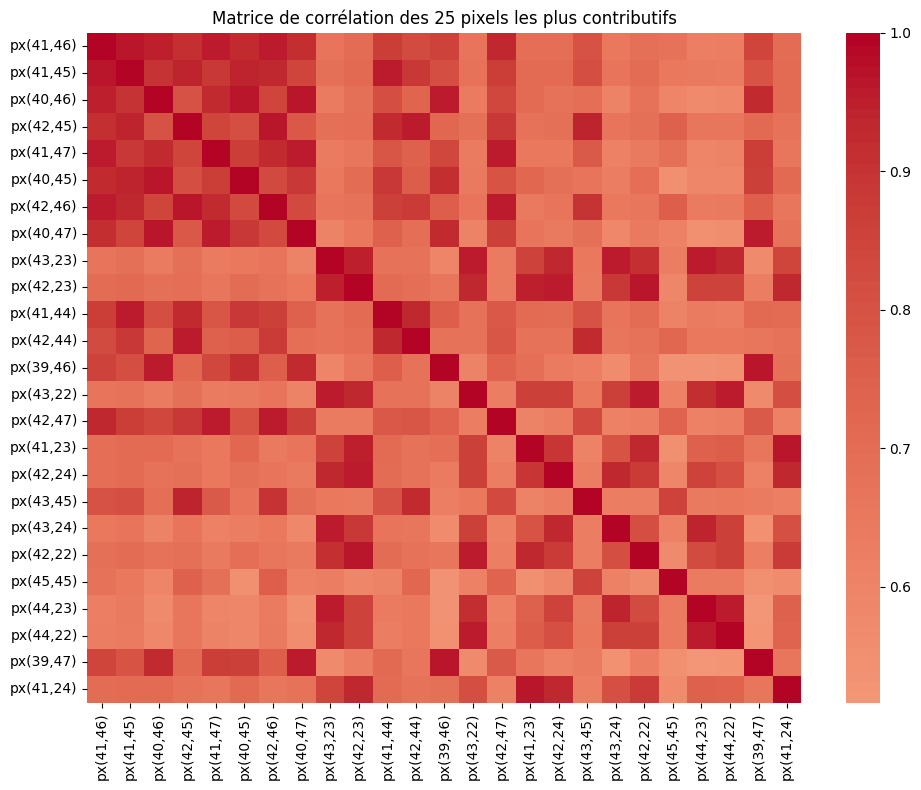

In [426]:

# 25 bis-F) MATRICE / GRAPHE DE CORRÉLATION DES VARIABLES IMPORTANTES


top_corr_idx = np.argsort(top_score)[::-1][:25]
Z_top = Z_tr[:, top_corr_idx]
R_top = np.corrcoef(Z_top, rowvar=False)
top_labels = [var_labels[i] for i in top_corr_idx]

R_top_df = pd.DataFrame(R_top, index=top_labels, columns=top_labels)
display(R_top_df.round(3).iloc[:10, :10])
R_top_df.to_csv(OUTPUT_DIR / "12_matrice_correlation_top_pixels.csv")

plt.figure(figsize=(10, 8))
sns.heatmap(R_top_df, cmap="coolwarm", center=0, xticklabels=True, yticklabels=True)
plt.title("Matrice de corrélation des 25 pixels les plus contributifs")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "12_heatmap_correlation_top_pixels.png", dpi=200, bbox_inches="tight")
plt.show()


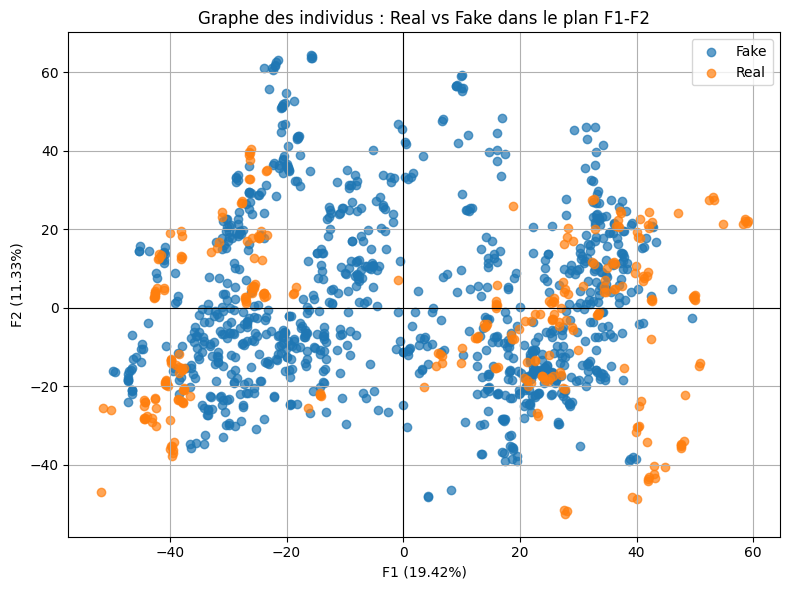

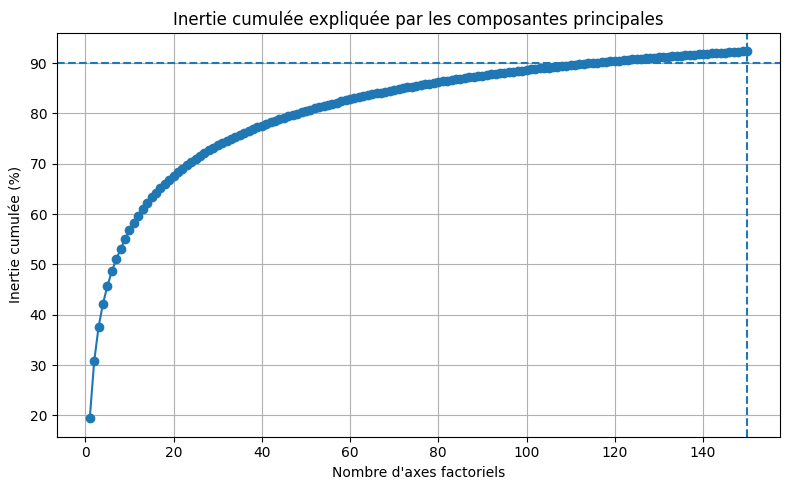

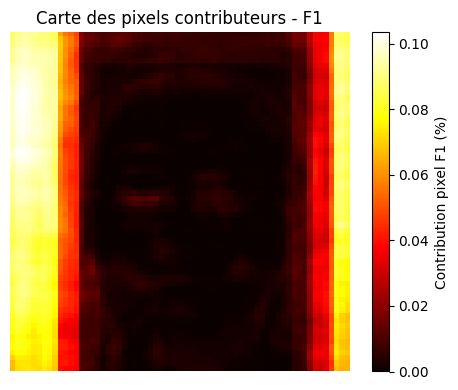

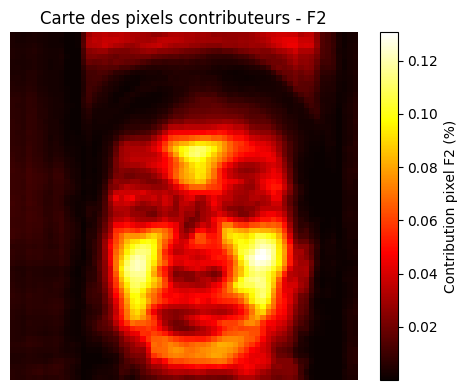

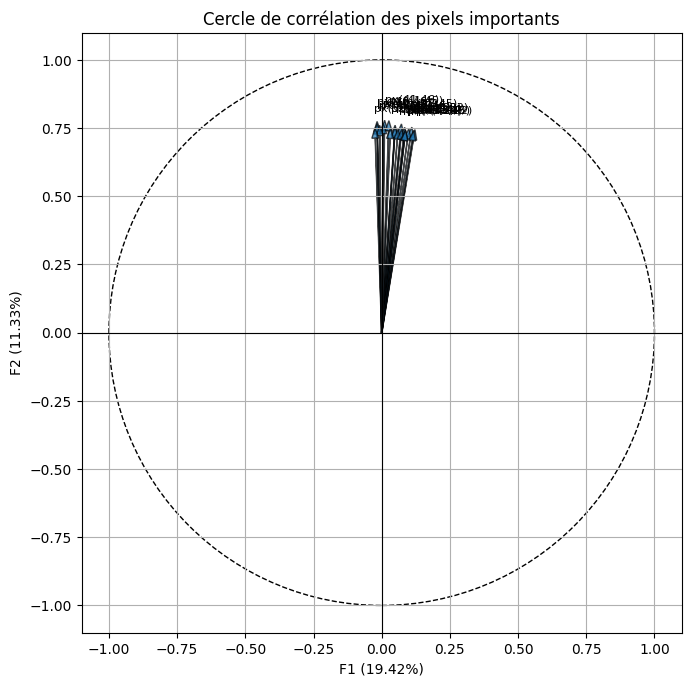

In [427]:

# 25 bis-G) FIGURES ACP À EXPORTER POUR LE RAPPORT


# 1) Graphe des individus F1-F2
plt.figure(figsize=(8, 6))
for lab in np.unique(y_tr):
    idx = (y_tr == lab)
    plt.scatter(C_tr_full[idx, 0], C_tr_full[idx, 1], label=CLASS_NAMES[int(lab)], alpha=0.7)
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel(f"F1 ({inertia_ratio[0]*100:.2f}%)")
plt.ylabel(f"F2 ({inertia_ratio[1]*100:.2f}%)")
plt.title("Graphe des individus : Real vs Fake dans le plan F1-F2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "13_graphe_individus_F1_F2.png", dpi=200, bbox_inches="tight")
plt.show()

# 2) Courbe inertie cumulée
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_inertia)+1), cum_inertia*100, marker="o")
plt.axhline(VARIANCE_TO_KEEP*100, linestyle="--")
plt.axvline(n_selected, linestyle="--")
plt.title("Inertie cumulée expliquée par les composantes principales")
plt.xlabel("Nombre d'axes factoriels")
plt.ylabel("Inertie cumulée (%)")
plt.grid(True)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "14_inertie_cumulee.png", dpi=200, bbox_inches="tight")
plt.show()

# 3) Carte des contributions des pixels pour F1 et F2
def contribution_map(axis=0):
    w, h = IMG_SIZE
    vals = var_contrib[:, axis]
    if MODALITY == "color_depth":
        vals = vals[:w*h]
    return vals.reshape(h, w)

for ax in range(min(2, n_axes_var)):
    plt.figure(figsize=(5, 4))
    plt.imshow(contribution_map(ax), cmap="hot")
    plt.colorbar(label=f"Contribution pixel F{ax+1} (%)")
    plt.title(f"Carte des pixels contributeurs - F{ax+1}")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"15_carte_contribution_pixels_F{ax+1}.png", dpi=200, bbox_inches="tight")
    plt.show()

# 4) Cercle de corrélation sauvegardé
fig, ax = plt.subplots(figsize=(7, 7))
circle = plt.Circle((0, 0), 1, fill=False, linestyle="--")
ax.add_artist(circle)
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8)

for idx in top_idx:
    x = var_coords[idx, 0]
    y = var_coords[idx, 1]
    ax.arrow(0, 0, x, y, head_width=0.025, length_includes_head=True, alpha=0.7)
    ax.text(x*1.08, y*1.08, var_labels[idx], fontsize=8)

ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_aspect("equal", "box")
ax.set_xlabel(f"F1 ({inertia_ratio[0]*100:.2f}%)")
ax.set_ylabel(f"F2 ({inertia_ratio[1]*100:.2f}%)")
ax.set_title("Cercle de corrélation des pixels importants")
ax.grid(True)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "16_cercle_correlation_pixels_importants.png", dpi=200, bbox_inches="tight")
plt.show()


In [428]:

# 26) SAUVEGARDE DU MODÈLE FINAL


final_scaler = StandardScaler(with_mean=True, with_std=True)
Z_all = final_scaler.fit_transform(X_train_raw)

final_max_comp = min(MAX_PCA_COMPONENTS, Z_all.shape[0] - 1, Z_all.shape[1])
final_pca = PCA(n_components=final_max_comp, svd_solver='randomized', random_state=RANDOM_STATE)
C_all_full = final_pca.fit_transform(Z_all)
final_cum = np.cumsum(final_pca.explained_variance_ratio_)

# On garde le nombre d'axes choisi plus haut pour le modèle, s'il est possible avec tout le train.
final_n_selected = min(int(n_selected), final_max_comp)
C_all = C_all_full[:, :final_n_selected]

# Recréer le modèle final pour éviter de réutiliser un objet déjà entraîné.
if 'SVM RBF' in best_model_name:
    final_model = SVC(kernel='rbf', C=10, gamma='scale',
                      class_weight='balanced' if USE_CLASS_WEIGHT_BALANCED else None,
                      probability=True, random_state=RANDOM_STATE)
elif 'SVM Linear' in best_model_name:
    final_model = SVC(kernel='linear', C=1,
                      class_weight='balanced' if USE_CLASS_WEIGHT_BALANCED else None,
                      probability=True, random_state=RANDOM_STATE)
elif 'Logistic' in best_model_name:
    final_model = LogisticRegression(max_iter=3000,
                                     class_weight='balanced' if USE_CLASS_WEIGHT_BALANCED else None,
                                     random_state=RANDOM_STATE)
elif 'Random Forest' in best_model_name:
    final_model = RandomForestClassifier(n_estimators=250,
                                         class_weight='balanced' if USE_CLASS_WEIGHT_BALANCED else None,
                                         random_state=RANDOM_STATE)
else:
    final_model = KNeighborsClassifier(n_neighbors=5)

final_model.fit(C_all, y_train_raw)

# Seuil calibré appris sur validation. S'il n'existe pas, on garde 0.50.
FINAL_REAL_THRESHOLD_FOR_EXTERNAL = float(globals().get('BEST_REAL_THRESHOLD', 0.50))


# Distance au centre du nuage dans le sous-espace ACP retenu.
# Cette mesure vient directement du cours/TP : un individu externe très éloigné
# du nuage d'apprentissage ne doit pas recevoir une décision trop sûre.
final_dist_train_acp = np.sum(C_all ** 2, axis=1)
FINAL_DISTANCE_THRESHOLD_ACP = float(np.percentile(final_dist_train_acp, EXTERNAL_DISTANCE_PERCENTILE))
print(f'Seuil distance ACP externe ({EXTERNAL_DISTANCE_PERCENTILE}e percentile) :', FINAL_DISTANCE_THRESHOLD_ACP)

bundle = {
    'scaler': final_scaler,
    'pca': final_pca,
    'n_selected': final_n_selected,
    'model': final_model,
    'class_names': CLASS_NAMES,
    'img_size': IMG_SIZE,
    'modality': MODALITY,
    'best_model_name': best_model_name,
    'variance_to_keep': VARIANCE_TO_KEEP,
    'confidence_threshold': EXTERNAL_CONFIDENCE_THRESHOLD,
    'real_threshold': FINAL_REAL_THRESHOLD_FOR_EXTERNAL,
    'external_real_threshold_default': EXTERNAL_REAL_THRESHOLD_DEFAULT,
    'external_fake_strong_threshold': EXTERNAL_FAKE_STRONG_THRESHOLD,
    'external_uncertainty_margin': EXTERNAL_UNCERTAINTY_MARGIN,
    'use_acp_distance_rejection': USE_ACP_DISTANCE_REJECTION,
    'external_distance_percentile': EXTERNAL_DISTANCE_PERCENTILE,
    'external_distance_threshold_acp': FINAL_DISTANCE_THRESHOLD_ACP,
    'use_clahe_for_all_images': USE_CLAHE_FOR_ALL_IMAGES,
    'n_selected_inertia': int(n_selected_inertia) if 'n_selected_inertia' in globals() else int(final_n_selected),
}

MODEL_PATH = Path('/content/face_antispoofing_acp_model.joblib')
joblib.dump(bundle, MODEL_PATH)
print('Modèle sauvegardé dans :', MODEL_PATH)

# Sauvegarde persistante dans Drive pour éviter de réentraîner à chaque session Colab.
try:
    CACHE_DIR_DRIVE.mkdir(parents=True, exist_ok=True)
    MODEL_PATH_DRIVE = CACHE_DIR_DRIVE / 'face_antispoofing_acp_model.joblib'
    joblib.dump(bundle, MODEL_PATH_DRIVE)
    print('Copie du modèle sauvegardée dans Drive :', MODEL_PATH_DRIVE)
except Exception as e:
    MODEL_PATH_DRIVE = None
    print('Sauvegarde Drive du modèle impossible :', e)
print('Composantes finales retenues :', final_n_selected)
print('Seuil de confiance externe :', EXTERNAL_CONFIDENCE_THRESHOLD)
print('CLAHE appliqué au dataset :', USE_CLAHE_FOR_ALL_IMAGES)
print('Seuil Real calibré sauvegardé :', FINAL_REAL_THRESHOLD_FOR_EXTERNAL)
print('Seuil Fake fort sauvegardé :', EXTERNAL_FAKE_STRONG_THRESHOLD)
print('Marge Incertain sauvegardée :', EXTERNAL_UNCERTAINTY_MARGIN)
print('Rejet distance ACP :', USE_ACP_DISTANCE_REJECTION)


Seuil distance ACP externe (95.0e percentile) : 6454.283203125
Modèle sauvegardé dans : \content\face_antispoofing_acp_model.joblib
Copie du modèle sauvegardée dans Drive : \content\drive\MyDrive\acp_face_cache\face_antispoofing_acp_model.joblib
Composantes finales retenues : 150
Seuil de confiance externe : 0.7
CLAHE appliqué au dataset : True
Seuil Real calibré sauvegardé : 0.2
Seuil Fake fort sauvegardé : 0.85
Marge Incertain sauvegardée : 0.1
Rejet distance ACP : True



## 26 bis) Option rapide pour les prochaines sessions Colab




In [429]:

# 26 bis) CHARGEMENT RAPIDE DU MODÈLE SAUVEGARDÉ


FAST_LOAD_SAVED_MODEL_ONLY = False  # mets True dans une nouvelle session si le modèle existe déjà dans Drive

if FAST_LOAD_SAVED_MODEL_ONLY:
    candidate_model = CACHE_DIR_DRIVE / 'face_antispoofing_acp_model.joblib'
    if candidate_model.exists():
        MODEL_PATH = candidate_model
        bundle_test = joblib.load(MODEL_PATH)
        final_n_selected = bundle_test['n_selected']
        print('Modèle rechargé rapidement depuis :', MODEL_PATH)
        print('Composantes ACP retenues :', final_n_selected)
        print('Modèle :', bundle_test.get('best_model_name', 'modèle sauvegardé'))
    else:
        print('Aucun modèle sauvegardé trouvé dans :', candidate_model)


In [430]:

# 27) TESTER UNE NOUVELLE IMAGE


def predict_one_image(image_path, model_path=MODEL_PATH):
    bundle = joblib.load(model_path)
    img_size = bundle['img_size']
    modality = bundle['modality']

    # Pour une seule image, on utilise la modalité color par défaut.
    # Si le modèle est color_depth, il faut fournir aussi une image depth correspondante.
    if modality == 'color_depth':
        print("Attention : le modèle a été entraîné en color_depth. Cette fonction simple utilise seulement color.")

    img = read_gray_resized(image_path, img_size)
    if img is None:
        raise ValueError('Image illisible : ' + str(image_path))

    x = img.flatten().astype(np.float32).reshape(1, -1)

    # Si le modèle final était color_depth, cette prédiction simple n'est pas suffisante.
    if x.shape[1] != bundle['scaler'].n_features_in_:
        raise ValueError(f"Dimension incorrecte : image={x.shape[1]}, modèle={bundle['scaler'].n_features_in_}. Vérifie MODALITY.")

    z = bundle['scaler'].transform(x)
    c_full = bundle['pca'].transform(z)
    c = c_full[:, :bundle['n_selected']]
    pred = int(bundle['model'].predict(c)[0])

    proba = None
    if hasattr(bundle['model'], 'predict_proba'):
        proba = bundle['model'].predict_proba(c)[0]

    return bundle['class_names'][pred], proba

# Exemple :
# IMAGE_PATH = '/content/drive/MyDrive/mon_image.jpg'
# prediction, proba = predict_one_image(IMAGE_PATH)
# print('Prediction :', prediction, 'Proba :', proba)


## 28) Test upload ou caméra 


In [431]:

# 28) OUTILS DE PRÉTRAITEMENT POUR IMAGE UPLOADÉE / CAMÉRA


from base64 import b64decode
from IPython.display import display, Javascript
'''
try:
    from google.colab import files
    from google.colab.output import eval_js
    COLAB_AVAILABLE = True
except Exception:
    COLAB_AVAILABLE = False
'''

def cv2_read_bgr(path):
    """Lecture robuste d'une image avec OpenCV, même si le nom contient des espaces."""
    path = str(path)
    data = np.fromfile(path, dtype=np.uint8)
    img = cv2.imdecode(data, cv2.IMREAD_COLOR)
    if img is None:
        img = cv2.imread(path, cv2.IMREAD_COLOR)
    return img


def get_face_cascade():
    cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
    cascade = cv2.CascadeClassifier(cascade_path)
    if cascade.empty():
        return None
    return cascade


def central_square_crop(img_bgr, ratio=0.88):
    """Crop central utilisé si aucun visage n'est détecté."""
    h, w = img_bgr.shape[:2]
    side = int(min(h, w) * ratio)
    y1 = max((h - side) // 2, 0)
    x1 = max((w - side) // 2, 0)
    return img_bgr[y1:y1+side, x1:x1+side]


def crop_face_or_center(img_bgr, margin=0.35):
    """Détecte le visage et le recadre. Si échec : crop central."""
    cascade = get_face_cascade()
    if cascade is None:
        return central_square_crop(img_bgr), 'crop_central'

    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    faces = cascade.detectMultiScale(gray, scaleFactor=1.08, minNeighbors=5, minSize=(40, 40))

    if len(faces) == 0:
        return central_square_crop(img_bgr), 'crop_central'

    x, y, w, h = max(faces, key=lambda r: r[2] * r[3])

    mx = int(w * margin)
    my = int(h * margin)
    x1 = max(x - mx, 0)
    y1 = max(y - my, 0)
    x2 = min(x + w + mx, img_bgr.shape[1])
    y2 = min(y + h + my, img_bgr.shape[0])

    crop = img_bgr[y1:y2, x1:x2]
    return crop, 'visage_detecte'


def to_gray_float(img_bgr, img_size):
    """Convertit en gris, redimensionne et normalise entre 0 et 1 comme dans le dataset."""
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, img_size)
    return gray.astype(np.float32) / 255.0


def apply_clahe(gray_float):
    """Amélioration légère du contraste pour réduire l'effet d'éclairage webcam."""
    gray_u8 = np.clip(gray_float * 255, 0, 255).astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    out = clahe.apply(gray_u8)
    return out.astype(np.float32) / 255.0


def make_test_variants(image_path, img_size):
    """
    Crée des versions adaptées à l'image externe.
    Par défaut, on donne priorité au visage recadré afin d'éviter que le fond
    ne perturbe la projection ACP.
    """
    img_bgr = cv2_read_bgr(image_path)
    if img_bgr is None:
        raise ValueError('Image illisible : ' + str(image_path))

    face_crop, crop_status = crop_face_or_center(img_bgr)
    center_crop = central_square_crop(img_bgr)

    variants = []

    face_gray = to_gray_float(face_crop, img_size)
    center_gray = to_gray_float(center_crop, img_size)
    full_gray = to_gray_float(img_bgr, img_size)

    if EXTERNAL_VARIANT_MODE == 'face_priority':
        variants.append((crop_status, face_gray))
        variants.append((crop_status + '_contraste', apply_clahe(face_gray)))
        variants.append((crop_status + '_miroir', np.fliplr(face_gray).copy()))
    else:
        variants.append(('image_entiere', full_gray))
        variants.append((crop_status, face_gray))
        variants.append(('crop_central_reference', center_gray))
        variants.append((crop_status + '_contraste', apply_clahe(face_gray)))
        variants.append((crop_status + '_miroir', np.fliplr(face_gray).copy()))

    return img_bgr, face_crop, variants


def show_test_preprocessing(image_path, img_bgr, face_crop, variants):
    """Affiche les étapes principales avant la prédiction."""
    plt.figure(figsize=(13, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    plt.title('Image originale')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(cv2.cvtColor(face_crop, cv2.COLOR_BGR2RGB))
    plt.title('Visage / crop utilisé')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(variants[1][1], cmap='gray')
    plt.title('Image donnée à ACP')
    plt.axis('off')

    plt.show()


In [432]:

# 29) PRÉDICTION D'UNE NOUVELLE IMAGE AVEC LE MÊME MODÈLE ACP


def decide_external(mean_fake, mean_real, class_names, real_threshold=0.50, uncertainty_threshold=0.70):
    """
    Décision améliorée pour les images externes.

    Problème observé : plusieurs vraies images personnelles sont prédites Fake.
    Solution ACP-compatible : utiliser le seuil Real calibré sur validation.

    Règle :
    - si proba Real >= seuil Real calibré -> Real ;
    - sinon, si la confiance globale est faible -> Incertain ;
    - sinon -> Fake.
    """
    if mean_real >= real_threshold:
        return class_names[1]
    if max(mean_fake, mean_real) < uncertainty_threshold:
        return 'Incertain'
    return class_names[0]


def predict_external_image_acp(image_path, model_path=MODEL_PATH, show_steps=True, verbose=True):
    """
    Prédit Real/Fake pour une image externe.
    On respecte le pipeline du projet : scaler appris -> ACP apprise -> classifieur appris.
    Aucun deuxième modèle n'est entraîné ici.

    Amélioration : décision avec seuil Real calibré pour réduire les vrais visages classés Fake.
    """
    bundle = joblib.load(model_path)

    scaler = bundle['scaler']
    pca = bundle['pca']
    model = bundle['model']
    n_selected = bundle['n_selected']
    class_names = bundle['class_names']
    img_size = bundle['img_size']
    modality = bundle.get('modality', 'color')
    uncertainty_threshold = bundle.get('confidence_threshold', EXTERNAL_CONFIDENCE_THRESHOLD)
    real_threshold = bundle.get('real_threshold', 0.50)

    if modality != 'color':
        raise ValueError(
            "Le test upload/caméra est prévu pour MODALITY='color'. "
            "La caméra Colab ne donne pas de depth. Réentraîne le notebook avec MODALITY='color'."
        )

    img_bgr, face_crop, variants = make_test_variants(image_path, img_size)

    if show_steps:
        show_test_preprocessing(image_path, img_bgr, face_crop, variants)

    all_probs = []
    detail_rows = []

    for variant_name, gray_img in variants:
        x = gray_img.flatten().astype(np.float32).reshape(1, -1)

        if x.shape[1] != scaler.n_features_in_:
            raise ValueError(
                f"Dimension incorrecte : image={x.shape[1]}, modèle={scaler.n_features_in_}. "
                "Vérifie IMG_SIZE et MODALITY."
            )

        # Même traitement que dans les TP ACP : centrage-réduction puis projection
        z = scaler.transform(x)
        c_full = pca.transform(z)
        c = c_full[:, :n_selected]

        pred_variant = int(model.predict(c)[0])

        if hasattr(model, 'predict_proba'):
            prob = model.predict_proba(c)[0]
            labels_order = list(model.classes_)
            prob_by_label = {int(lab): float(prob[i]) for i, lab in enumerate(labels_order)}
        else:
            prob_by_label = {0: 0.0, 1: 0.0}
            prob_by_label[pred_variant] = 1.0

        all_probs.append(prob_by_label)
        detail_rows.append({
            'Version testée': variant_name,
            'Prédiction brute': class_names[pred_variant],
            'Proba Fake (%)': prob_by_label.get(0, 0.0) * 100,
            'Proba Real (%)': prob_by_label.get(1, 0.0) * 100,
        })

    mean_fake = float(np.mean([p.get(0, 0.0) for p in all_probs]))
    mean_real = float(np.mean([p.get(1, 0.0) for p in all_probs]))

    final_prediction = decide_external(
        mean_fake,
        mean_real,
        class_names,
        real_threshold=real_threshold,
        uncertainty_threshold=uncertainty_threshold
    )
    details_df = pd.DataFrame(detail_rows)

    if verbose:
        print('=' * 55)
        print('Résultat de la classification après ACP')
        print('=' * 55)
        print('Image :', Path(image_path).name)
        print('Modèle utilisé :', bundle.get('best_model_name', type(model).__name__))
        print('Nombre de composantes ACP retenues :', n_selected)
        print(f'Seuil Real calibré : {real_threshold*100:.1f}%')
        print(f'Seuil Incertain : {uncertainty_threshold*100:.0f}%')
        print('Prédiction finale :', final_prediction)
        print('\nProbabilités moyennes :')
        print(f'- Fake : {mean_fake * 100:.2f}%')
        print(f'- Real : {mean_real * 100:.2f}%')
        print('\nDétail par variante de prétraitement :')
        display(details_df)

        if final_prediction == 'Incertain':
            print('\nInterprétation : le modèle n\'est pas assez sûr. Les images externes peuvent différer du dataset.')
        elif final_prediction == class_names[1] and mean_real < 0.50:
            print('\nRemarque : Real a été accepté grâce au seuil calibré. Cette calibration est apprise sur la validation après ACP.')

    return final_prediction, {'Fake': mean_fake, 'Real': mean_real}, details_df


## 29 bis) Décision externe corrigée : seuil Real, zone Incertain et distance au centre ACP

Cette cellule remplace la décision finale brute. Elle reste conforme au cours ACP : l'image externe est projetée dans le même sous-espace factoriel, puis la décision tient compte de la proximité au nuage d'apprentissage et de la confiance Real/Fake.


In [433]:

# 29 bis) DÉCISION EXTERNE CORRIGÉE : ACP + SEUIL + INCERTAIN



def make_test_variants(image_path, img_size):
    """
    Variantes pour image externe.
    Correction importante : on évite de multiplier trop de variantes, car la moyenne
    de variantes peut transformer une vraie image en Fake.

    On garde seulement :
    1) visage recadré ou crop central ;
    2) même image avec contraste léger CLAHE.
    """
    img_bgr = cv2_read_bgr(image_path)
    if img_bgr is None:
        raise ValueError('Image illisible : ' + str(image_path))

    face_crop, crop_status = crop_face_or_center(img_bgr)
    face_gray = to_gray_float(face_crop, img_size)

    variants = [
        (crop_status, face_gray),
        (crop_status + '_contraste', apply_clahe(face_gray)),
    ]

    return img_bgr, face_crop, variants


def decide_external(mean_fake, mean_real, class_names,
                    real_threshold=0.35,
                    fake_strong_threshold=0.85,
                    uncertainty_margin=0.15,
                    distance_acp=None,
                    distance_threshold=None,
                    use_distance_rejection=True):
    """
    Décision externe ACP-compatible.

    Règles :
    - Si l'image est trop loin du nuage d'apprentissage dans l'espace ACP -> Incertain.
    - Si Fake est très sûr -> Fake.
    - Si Real dépasse un seuil calibré et que Fake n'est pas fortement dominant -> Real.
    - Si les probabilités sont proches -> Incertain.
    - Sinon -> Fake par prudence anti-spoofing.
    """
    fake_name = class_names[0] if isinstance(class_names, dict) else class_names[0]
    real_name = class_names[1] if isinstance(class_names, dict) else class_names[1]

    # 1) Rejet par distance au centre du nuage ACP
    if use_distance_rejection and distance_acp is not None and distance_threshold is not None:
        if distance_acp > distance_threshold:
            return 'Incertain'

    # 2) Fake très sûr : attaque probable
    if mean_fake >= fake_strong_threshold:
        return fake_name

    # 3) Real acceptable : seuil abaissé pour réduire Real -> Fake sur images externes
    # On accepte Real seulement si Fake n'est pas trop dominant.
    if mean_real >= real_threshold and (mean_real - mean_fake) >= -uncertainty_margin:
        return real_name

    # 4) Zone proche : ne pas forcer une mauvaise classe
    if abs(mean_fake - mean_real) < uncertainty_margin:
        return 'Incertain'

    # 5) Par prudence, sinon Fake
    return fake_name


def predict_external_image_acp(image_path, model_path=MODEL_PATH, show_steps=True, verbose=True):
    """
    Prédit Real/Fake pour une image externe.
    On respecte le pipeline du projet : scaler appris -> ACP apprise -> classifieur appris.

    Cette version améliore les vrais visages externes en évitant les décisions Fake faibles :
    - seuil Real calibré ;
    - zone Incertain ;
    - rejet si l'image est trop loin du nuage ACP d'apprentissage.
    """
    bundle = joblib.load(model_path)

    scaler = bundle['scaler']
    pca = bundle['pca']
    model = bundle['model']
    n_selected = bundle['n_selected']
    class_names = bundle['class_names']
    img_size = bundle['img_size']
    modality = bundle.get('modality', 'color')

    # Seuils sauvegardés ou valeurs de secours
    real_threshold = float(bundle.get('real_threshold', bundle.get('external_real_threshold_default', EXTERNAL_REAL_THRESHOLD_DEFAULT)))
    # Si la calibration a donné un seuil trop haut, on garde un seuil externe plus raisonnable.
    real_threshold = min(real_threshold, 0.45)
    fake_strong_threshold = float(bundle.get('external_fake_strong_threshold', EXTERNAL_FAKE_STRONG_THRESHOLD))
    uncertainty_margin = float(bundle.get('external_uncertainty_margin', EXTERNAL_UNCERTAINTY_MARGIN))
    use_distance_rejection = bool(bundle.get('use_acp_distance_rejection', USE_ACP_DISTANCE_REJECTION))
    distance_threshold = bundle.get('external_distance_threshold_acp', None)

    if modality != 'color':
        raise ValueError(
            "Le test upload/caméra est prévu pour MODALITY='color'. "
            "La caméra Colab ne donne pas de depth. Réentraîne le notebook avec MODALITY='color'."
        )

    img_bgr, face_crop, variants = make_test_variants(image_path, img_size)

    if show_steps:
        show_test_preprocessing(image_path, img_bgr, face_crop, variants)

    all_probs = []
    detail_rows = []
    distances = []

    for variant_name, gray_img in variants:
        x = gray_img.flatten().astype(np.float32).reshape(1, -1)

        if x.shape[1] != scaler.n_features_in_:
            raise ValueError(
                f"Dimension incorrecte : image={x.shape[1]}, modèle={scaler.n_features_in_}. "
                "Vérifie IMG_SIZE et MODALITY."
            )

        # Même traitement que dans les TP ACP : centrage-réduction puis projection
        z = scaler.transform(x)
        c_full = pca.transform(z)
        c = c_full[:, :n_selected]
        distance_acp = float(np.sum(c ** 2))
        distances.append(distance_acp)

        pred_variant = int(model.predict(c)[0])

        if hasattr(model, 'predict_proba'):
            prob = model.predict_proba(c)[0]
            labels_order = list(model.classes_)
            prob_by_label = {int(lab): float(prob[i]) for i, lab in enumerate(labels_order)}
        else:
            prob_by_label = {0: 0.0, 1: 0.0}
            prob_by_label[pred_variant] = 1.0

        all_probs.append(prob_by_label)
        detail_rows.append({
            'Version testée': variant_name,
            'Prédiction brute': class_names[pred_variant],
            'Proba Fake (%)': prob_by_label.get(0, 0.0) * 100,
            'Proba Real (%)': prob_by_label.get(1, 0.0) * 100,
            'Distance ACP': distance_acp,
        })

    mean_fake = float(np.mean([p.get(0, 0.0) for p in all_probs]))
    mean_real = float(np.mean([p.get(1, 0.0) for p in all_probs]))
    mean_distance_acp = float(np.mean(distances))

    final_prediction = decide_external(
        mean_fake,
        mean_real,
        class_names,
        real_threshold=real_threshold,
        fake_strong_threshold=fake_strong_threshold,
        uncertainty_margin=uncertainty_margin,
        distance_acp=mean_distance_acp,
        distance_threshold=distance_threshold,
        use_distance_rejection=use_distance_rejection,
    )

    details_df = pd.DataFrame(detail_rows)

    if verbose:
        print('=' * 60)
        print('Résultat de la classification après ACP')
        print('=' * 60)
        print('Image :', Path(image_path).name)
        print('Modèle utilisé :', bundle.get('best_model_name', type(model).__name__))
        print('Nombre de composantes ACP utilisées :', n_selected)
        print(f'Probabilité moyenne Fake : {mean_fake*100:.2f}%')
        print(f'Probabilité moyenne Real : {mean_real*100:.2f}%')
        print(f'Distance ACP moyenne : {mean_distance_acp:.4f}')
        if distance_threshold is not None:
            print(f'Seuil distance ACP : {float(distance_threshold):.4f}')
        print(f'Seuil Real utilisé : {real_threshold:.2f}')
        print(f'Seuil Fake fort : {fake_strong_threshold:.2f}')
        print(f'Marge Incertain : {uncertainty_margin:.2f}')
        print('Prédiction finale :', final_prediction)
        print('\nDétails par variante :')
        display(details_df)

    return final_prediction, {'Fake': mean_fake, 'Real': mean_real, 'Distance ACP': mean_distance_acp}, details_df


In [434]:

# 30) UPLOAD IMAGE OU CAMÉRA - LOCAL VERSION



def upload_image_local():
    """Local file picker for image upload."""
    from tkinter import Tk, filedialog
    import os
    
    root = Tk()
    root.withdraw()
    root.attributes('-topmost', True)
    
    file_path = filedialog.askopenfilename(
        title="Sélectionnez une image",
        filetypes=[("Images", "*.jpg *.jpeg *.png *.bmp"), ("All", "*.*")]
    )
    root.destroy()
    
    if not file_path:
        raise ValueError('Aucune image sélectionnée.')
    
    return file_path


def take_photo_webcam(filename='photo_camera_local.jpg', quality=0.90):
    """Capture une photo avec la webcam du PC (local version)."""
    import cv2
    
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        raise RuntimeError("Impossible d'accéder à la caméra.")
    
    print("Appuyez sur SPACE pour prendre une photo, ESC pour annuler...")
    frame = None
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        cv2.imshow('Webcam - Appuyez sur SPACE pour capturer', frame)
        key = cv2.waitKey(1) & 0xFF
        
        if key == ord(' '):  # SPACE
            break
        elif key == 27:  # ESC
            cap.release()
            cv2.destroyAllWindows()
            raise RuntimeError("Capture annulée par l'utilisateur.")
    
    cap.release()
    cv2.destroyAllWindows()
    
    if frame is not None:
        cv2.imwrite(filename, frame)
        return filename
    else:
        raise RuntimeError("Impossible de capturer une photo.")


def run_interactive_test(TEST_MODE='upload'):
    """
    TEST_MODE = 'upload'  : sélectionner une image depuis le disque
    TEST_MODE = 'camera'  : prendre une photo avec la webcam
    """
    TEST_MODE = TEST_MODE.lower().strip()

    if TEST_MODE == 'upload':
        print('Mode choisi : upload image (file picker)')
        image_path = upload_image_local()
    elif TEST_MODE == 'camera':
        print('Mode choisi : caméra locale (webcam)')
        image_path = take_photo_webcam()
    else:
        raise ValueError("TEST_MODE doit être 'upload' ou 'camera'.")

    return predict_external_image_acp(image_path, MODEL_PATH, show_steps=True, verbose=True)


Mode choisi : caméra locale (webcam)
Appuyez sur SPACE pour prendre une photo, ESC pour annuler...


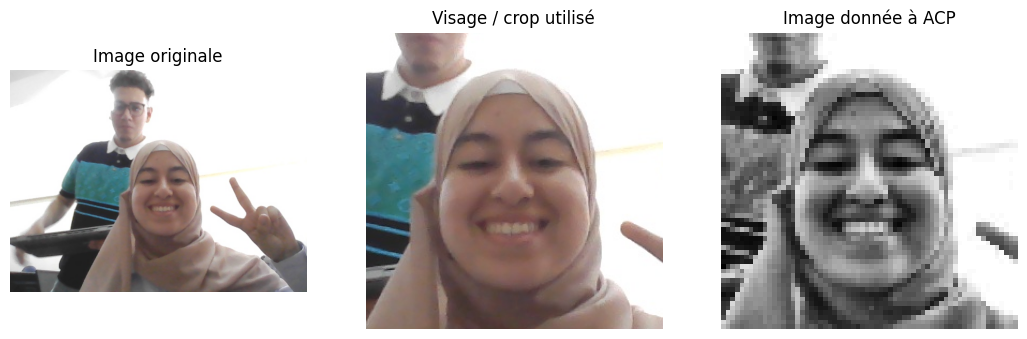

Résultat de la classification après ACP
Image : photo_camera_local.jpg
Modèle utilisé : SVM RBF équilibré
Nombre de composantes ACP utilisées : 150
Probabilité moyenne Fake : 10.48%
Probabilité moyenne Real : 89.52%
Distance ACP moyenne : 9897.3501
Seuil distance ACP : 6454.2832
Seuil Real utilisé : 0.20
Seuil Fake fort : 0.85
Marge Incertain : 0.10
Prédiction finale : Incertain

Détails par variante :


,Version testée,Prédiction brute,Proba Fake (%),Proba Real (%),Distance ACP
0,visage_detecte,Real,13.166875,86.833125,9582.508789
1,visage_detecte_contraste,Real,7.791045,92.208955,10212.191406


In [438]:

# 31) LANCER LE TEST FINAL


TEST_MODE = 'camera'   # change en 'camera' 

prediction, probabilities, details = run_interactive_test(TEST_MODE)


Mode choisi : caméra locale (webcam)
Appuyez sur SPACE pour prendre une photo, ESC pour annuler...


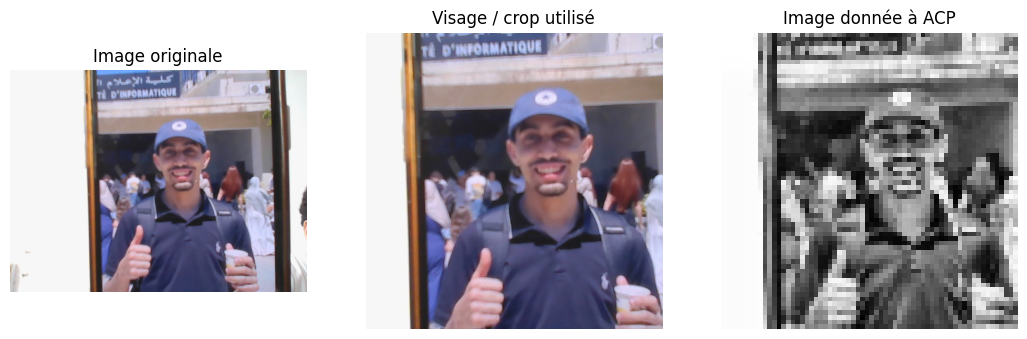

Résultat de la classification après ACP
Image : photo_camera_local.jpg
Modèle utilisé : SVM RBF équilibré
Nombre de composantes ACP utilisées : 150
Probabilité moyenne Fake : 60.19%
Probabilité moyenne Real : 39.81%
Distance ACP moyenne : 5906.3313
Seuil distance ACP : 6454.2832
Seuil Real utilisé : 0.20
Seuil Fake fort : 0.85
Marge Incertain : 0.10
Prédiction finale : Fake

Détails par variante :


,Version testée,Prédiction brute,Proba Fake (%),Proba Real (%),Distance ACP
0,crop_central,Fake,59.089712,40.910288,6216.681152
1,crop_central_contraste,Fake,61.290561,38.709439,5595.981445


In [ ]:

# 31) LANCER LE TEST FINAL


TEST_MODE = 'camera'   # change en 'camera' pour utiliser la caméra Colab

prediction, probabilities, details = run_interactive_test(TEST_MODE)
